In [24]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import griddata
import scienceplots
plt.style.use('science')
plt.style.use('nature')



#### Sampled nodes-300

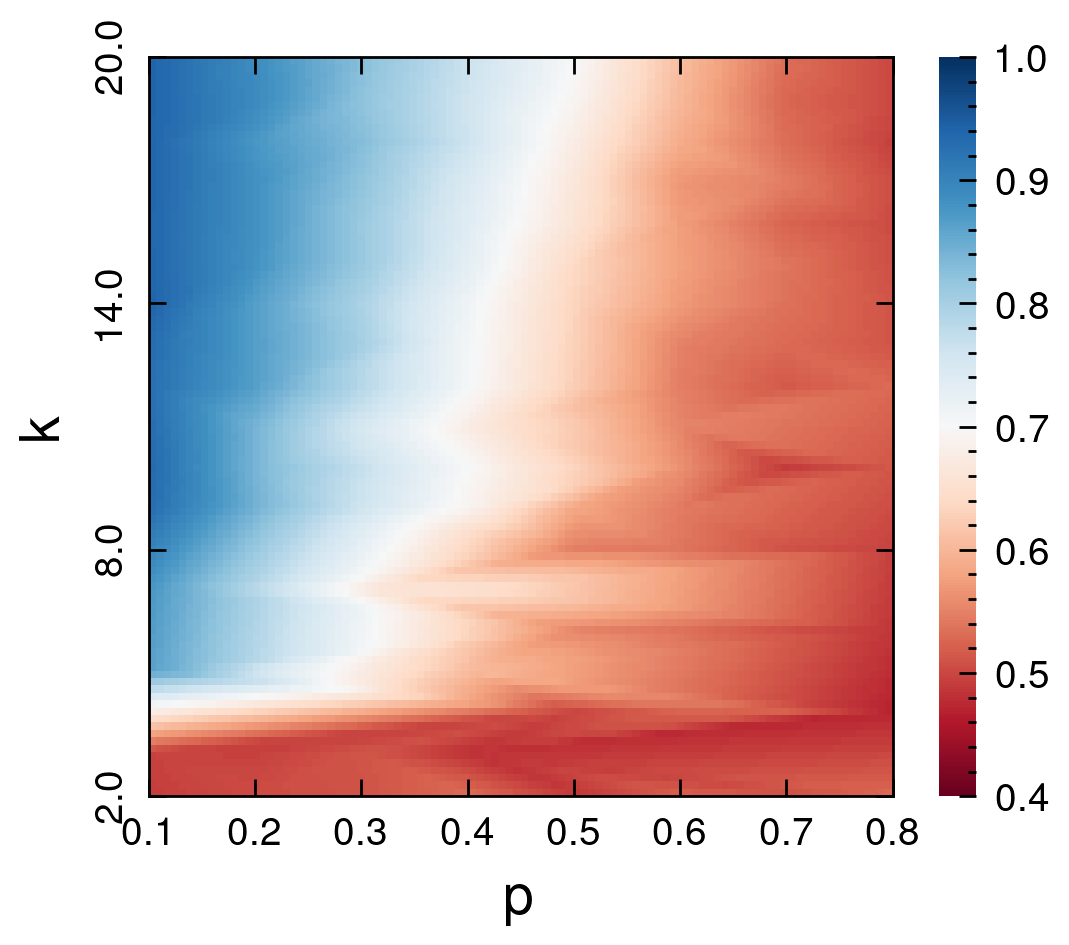

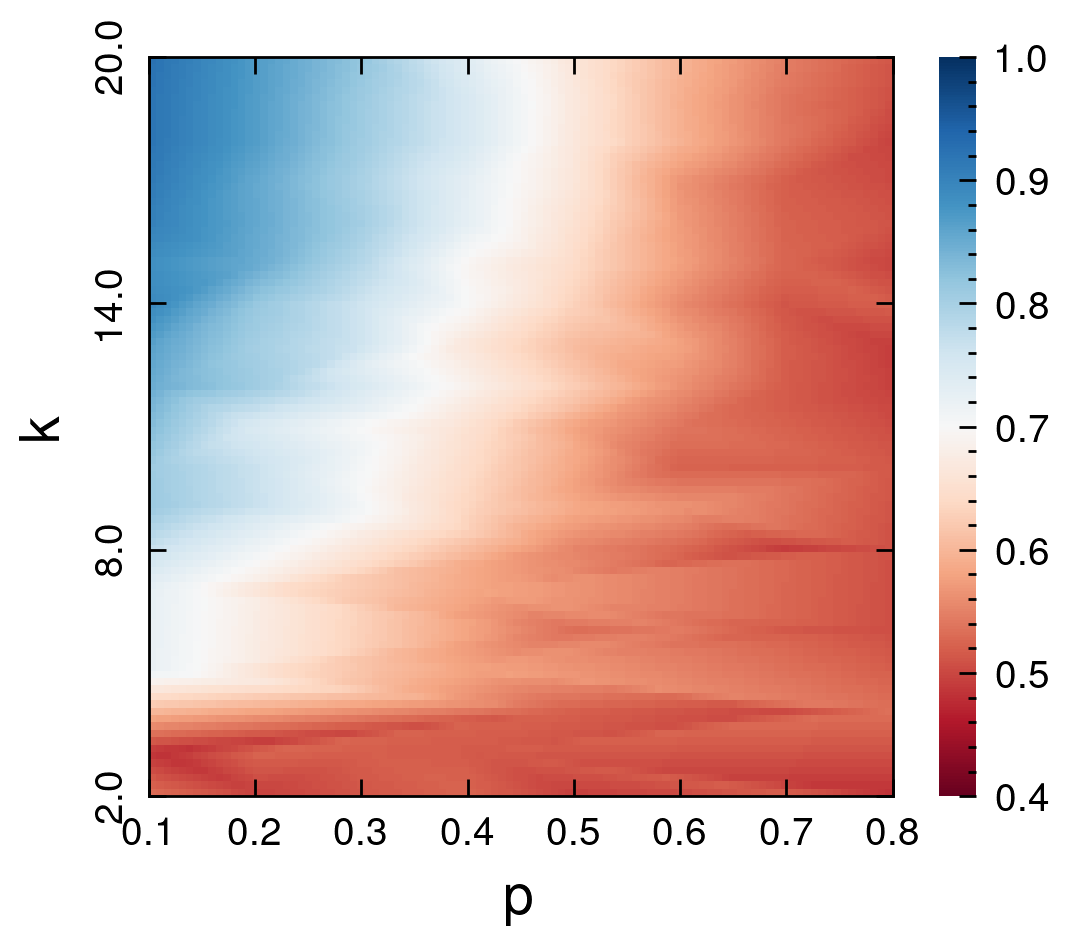

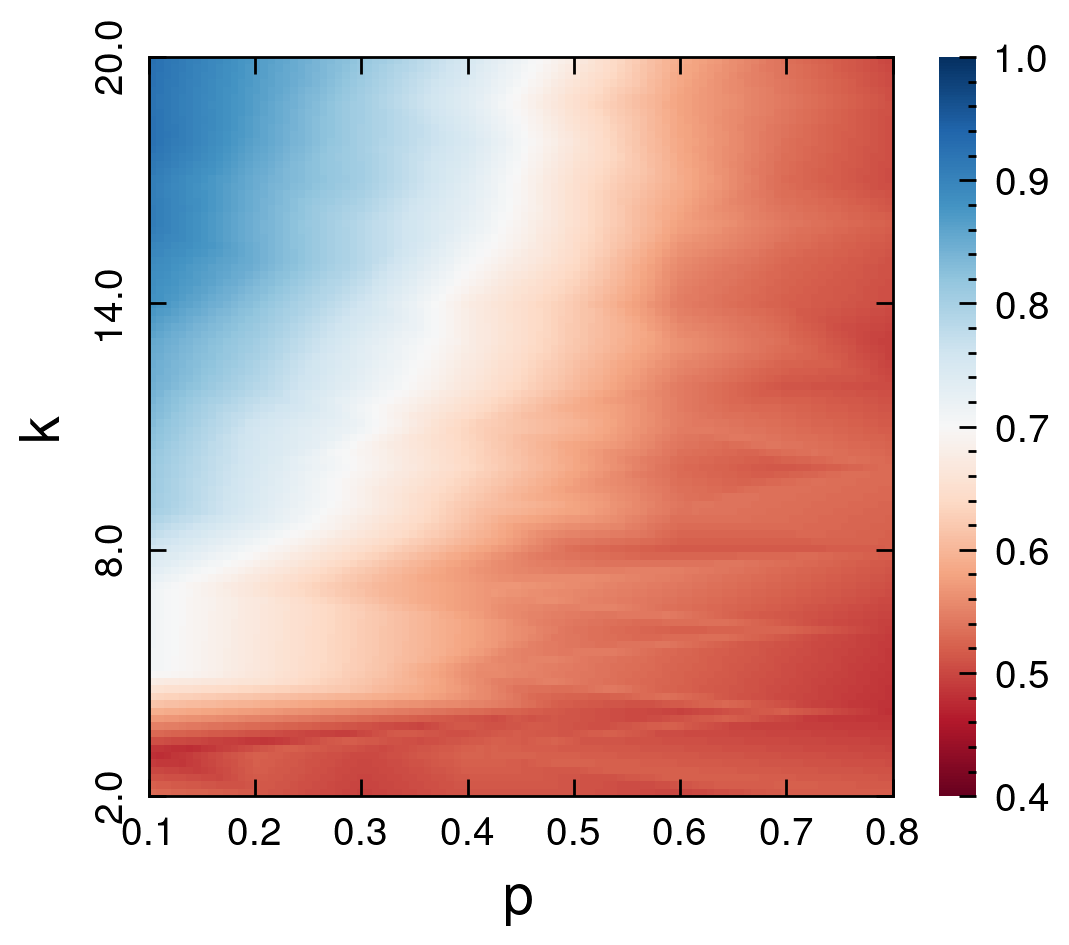

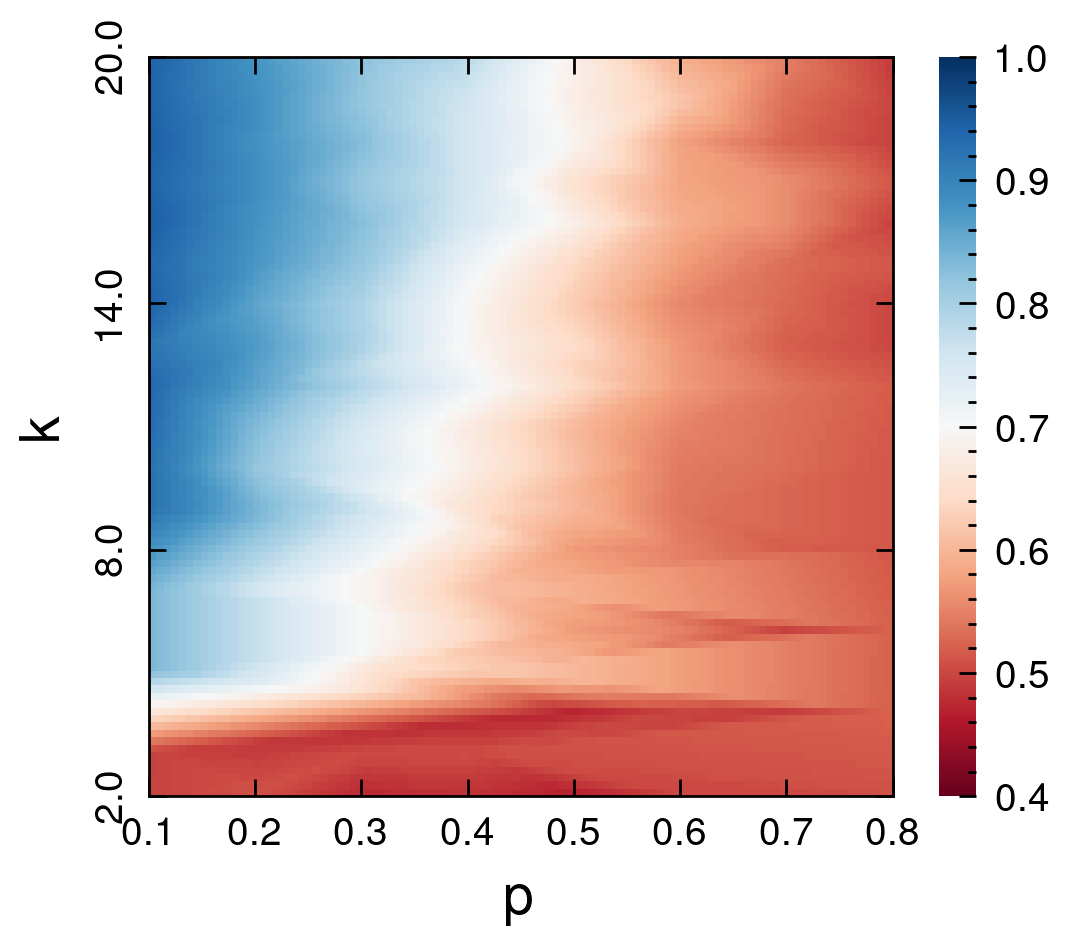

In [ ]:
data_300 = pd.read_csv('ws_degree_300.csv')
df = data_300.drop_duplicates(subset=['k', 'p'])
df
X1 = data_300['p']
Y1 = data_300['k'][::-1]


for measure in ['sn_auc','tn_auc','un_auc','rn_auc']:
    Values1 = data_300[measure]
    
    X = X1# + X2
    Y = Y1 #+ Y2
    Values = Values1 #+ Values2

    
    x_min, x_max = min(X), max(X)
    y_min, y_max = min(Y), max(Y)

    
    x_range = np.linspace(x_min, x_max, 100)
    y_range = np.linspace(y_min, y_max, 100)
    X_grid, Y_grid = np.meshgrid(x_range, y_range)

    
    points = np.array([X, Y]).T
    values = np.array(Values)
    Z_interpolated = griddata(points, values, (X_grid, Y_grid), method='linear')

    
    mask = np.isnan(Z_interpolated)


    fig, ax = plt.subplots(figsize=(3, 2.4), dpi=400)
    vmin = 0.4#max(min(values), np.percentile(values, 25)) 
    vmax = 1 # max(values)

  
    x_ticks = np.linspace(x_min, x_max, 8 )  
    y_ticks = np.linspace(y_max, y_min, 4)  

   
    sns.heatmap(Z_interpolated, mask=mask, annot=False, cmap='RdBu', vmin=vmin, vmax=vmax)#, 
                # xticklabels=np.round(x_ticks, 2), yticklabels=np.round(y_ticks, 2))

    # plt.xticks(np.linspace(0.1,0.8,7))
    # plt.title('',fontsize=5)
    plt.ylabel('k',fontsize=10)
    plt.xlabel('p',fontsize=10)

 
    ax = plt.gca()


    ax.set_xticks(np.linspace(0, Z_interpolated.shape[1],8))  
    ax.set_yticks(np.linspace(0, Z_interpolated.shape[0], 4))  

    x_labels = np.round(np.linspace(x_min, x_max, 8),1)
    y_labels = np.linspace(y_min, y_max, 4)[::-1]
    ax.set_xticklabels(x_labels)
    ax.set_yticklabels(y_labels)
    # ax.set_xlim([0,1])

    ax.tick_params(axis='both', which='minor', bottom=False, top=False, left=False, right=False)

    # 
    ax.spines['top'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['left'].set_visible(True)


    filename = f'C:\\Users\\WENJIA\\Downloads\\wsnet\\wsnet_{measure}_degree_auc_300.pdf'
    fig.savefig(filename, dpi=800)
    plt.show()


 

C:\Users\WENJIA\AppData\Local\Temp\ipykernel_46824\238683628.py:58: UserWarning: FixedFormatter should only be used together with FixedLocator
  cbar.set_ticklabels(np.round(cbar.get_ticks(), 2))  # 四舍五入到两位小数


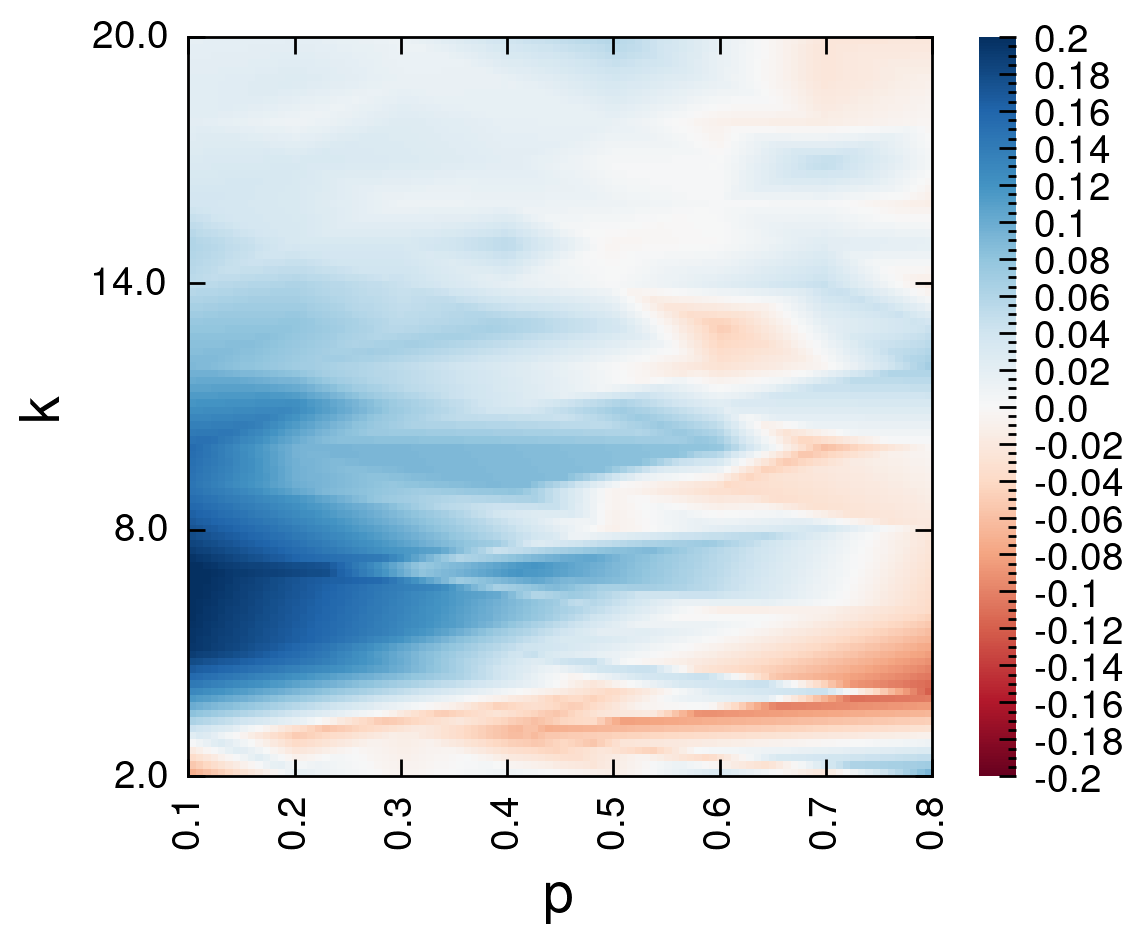

In [ ]:
import matplotlib.ticker as ticker
from matplotlib.colors import BoundaryNorm
Values1 = data_300['sn_auc']

X = X1# + X2
Y = Y1 #+ Y2
Values = Values1 #+ Values2

x_min, x_max = min(X), max(X)
y_min, y_max = min(Y), max(Y)

x_range = np.linspace(x_min, x_max, 100)
y_range = np.linspace(y_min, y_max, 100)
X_grid, Y_grid = np.meshgrid(x_range, y_range)

points = np.array([X, Y]).T
values = np.array(Values)
Z_interpolated_sn = griddata(points, values, (X_grid, Y_grid), method='linear')

Values1 = data_300['tn_auc']

X = X1# + X2
Y = Y1 #+ Y2
Values = Values1 #+ Values2

x_min, x_max = min(X), max(X)
y_min, y_max = min(Y), max(Y)

x_range = np.linspace(x_min, x_max, 100)
y_range = np.linspace(y_min, y_max, 100)
X_grid, Y_grid = np.meshgrid(x_range, y_range)

points = np.array([X, Y]).T
values = np.array(Values)
Z_interpolated_tn = griddata(points, values, (X_grid, Y_grid), method='linear')

Z_interpolated_imp = (Z_interpolated_sn - Z_interpolated_tn)/Z_interpolated_tn



mask = np.isnan(Z_interpolated_imp)

# 
fig, ax = plt.subplots(figsize=(3, 2.4), dpi=400)
vmin = -0.2#max(min(values), np.percentile(values, 25)) 
vmax = 0.2 # max(values)

# 
x_ticks = np.linspace(x_min, x_max, 8 )  
y_ticks = np.linspace(y_max, y_min, 4)  

# 
heatmap =sns.heatmap(Z_interpolated_imp, mask=mask, annot=False, cmap='RdBu', vmin=vmin, vmax=vmax, \
            xticklabels=np.round(x_ticks, 2), yticklabels=np.round(y_ticks, 2))

cbar = heatmap.collections[0].colorbar
cbar.set_ticks(ticker.MultipleLocator(base=0.02))  
cbar.set_ticklabels(np.round(cbar.get_ticks(), 2))  # 

# plt.xticks(np.linspace(0.1,0.8,7))
# plt.title('',fontsize=5)
plt.ylabel('k',fontsize=10)
plt.xlabel('p',fontsize=10)

# 
ax = plt.gca()

# 
ax.set_xticks(np.linspace(0, Z_interpolated_imp.shape[1],8))  
ax.set_yticks(np.linspace(0, Z_interpolated_imp.shape[0], 4))  

x_labels = np.round(np.linspace(x_min, x_max, 8),1)
y_labels = np.linspace(y_min, y_max, 4)[::-1]
ax.set_xticklabels(x_labels)
ax.set_yticklabels(y_labels)
# ax.set_xlim([0,1])

ax.tick_params(axis='both', which='minor', bottom=False, top=False, left=False, right=False)

# 
ax.spines['top'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['left'].set_visible(True)



filename = f'C:\\Users\\WENJIA\\Downloads\\wsnet\\wsnet_{measure}_degree_auc_imp_300.pdf'
fig.savefig(filename, dpi=300)
plt.show()


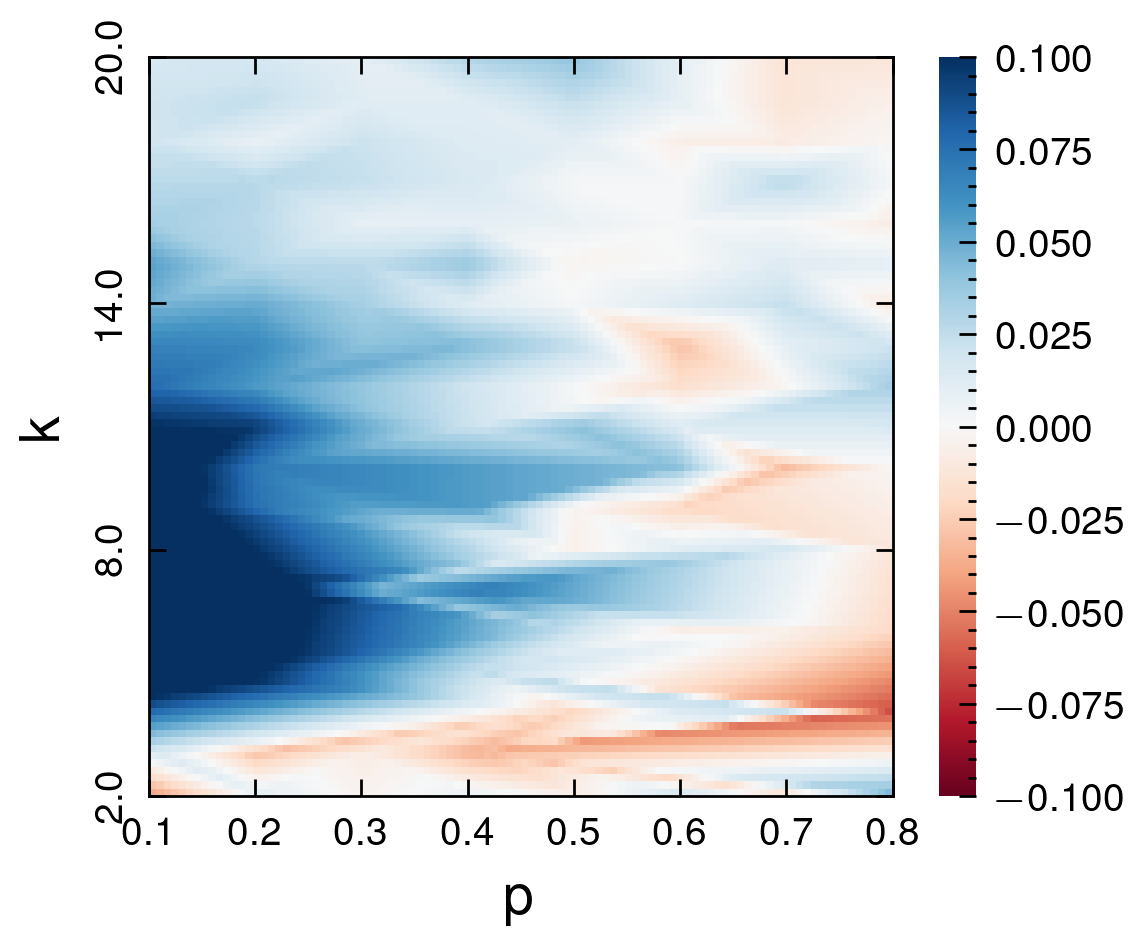

In [ ]:


mask_sn = np.isnan(Z_interpolated)
mask_sn.shape

#### Top nodes-300

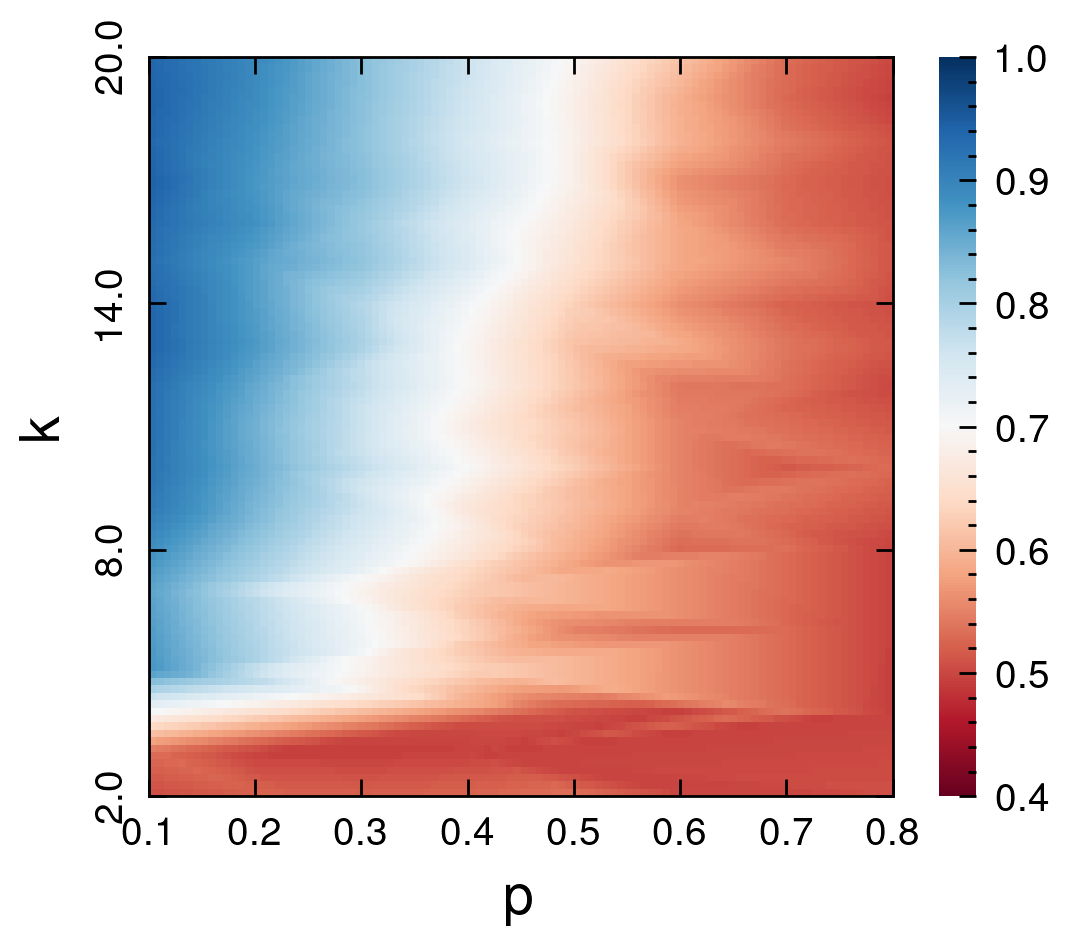

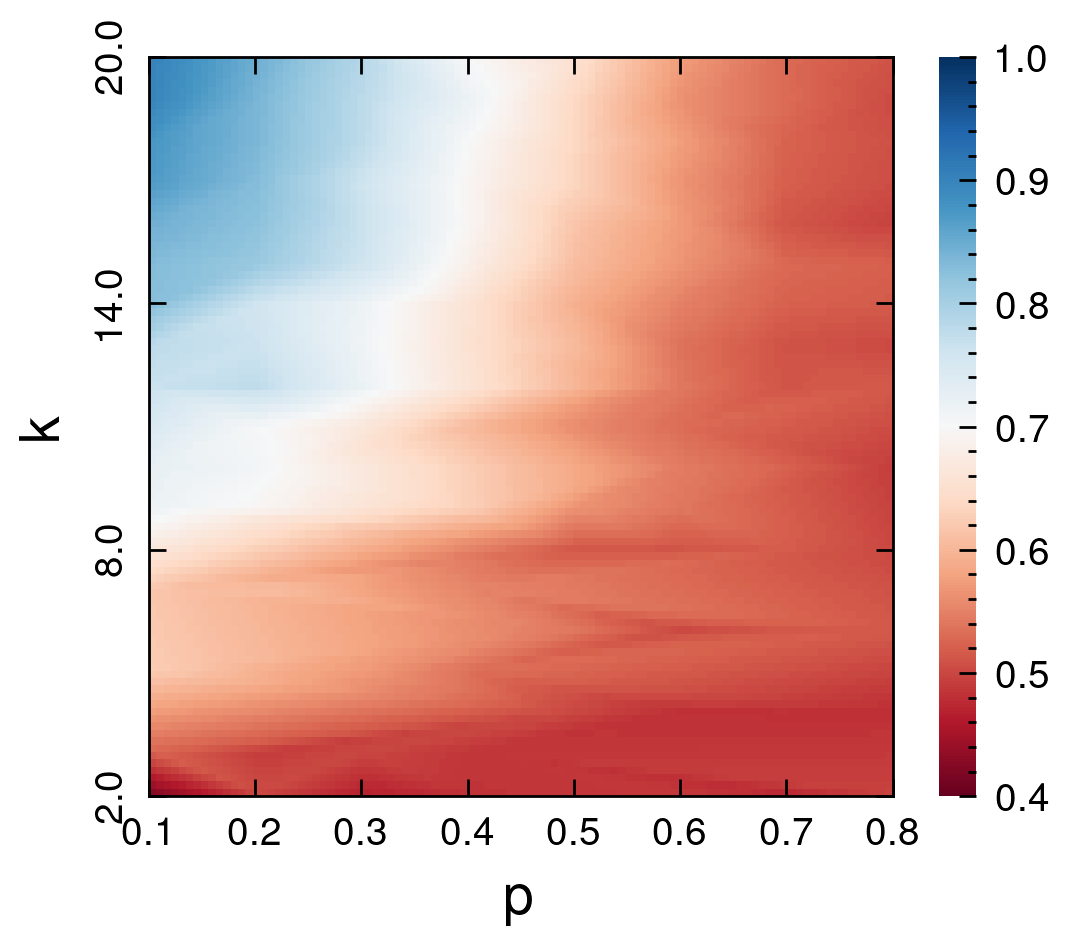

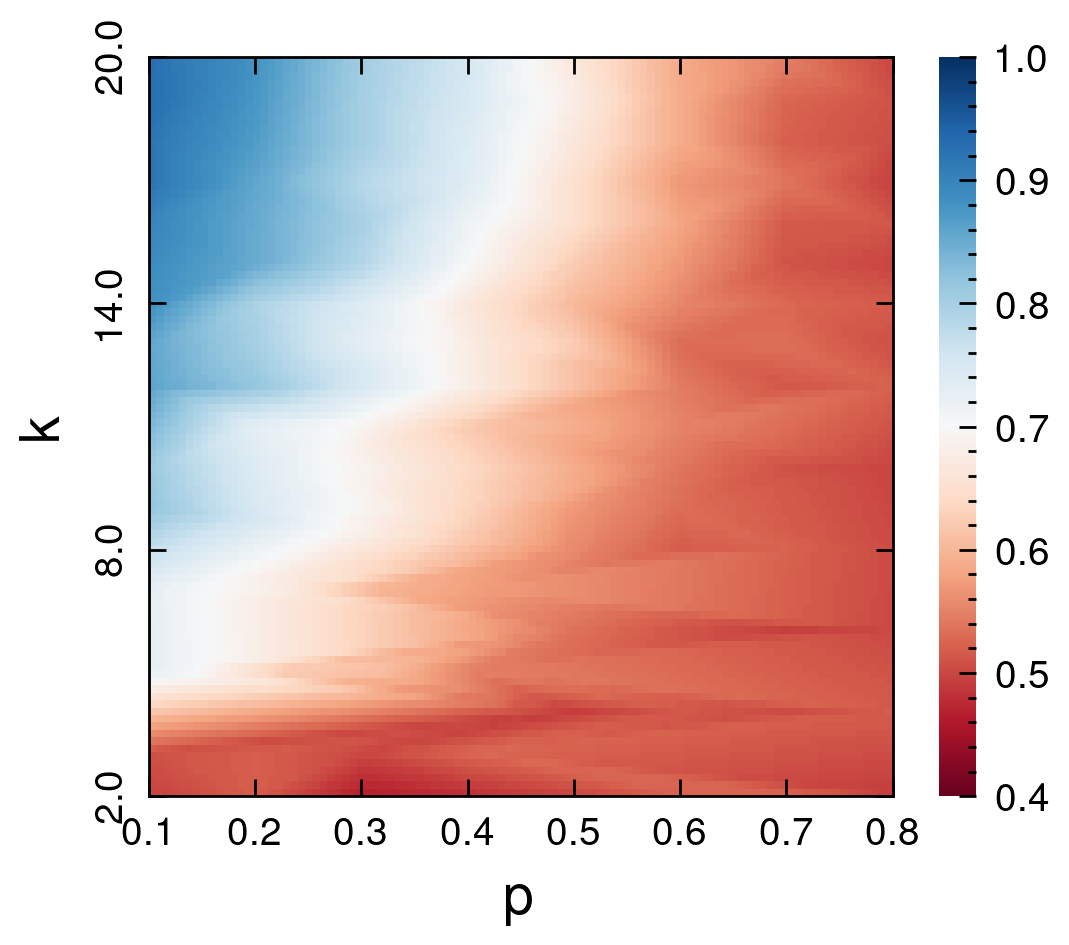

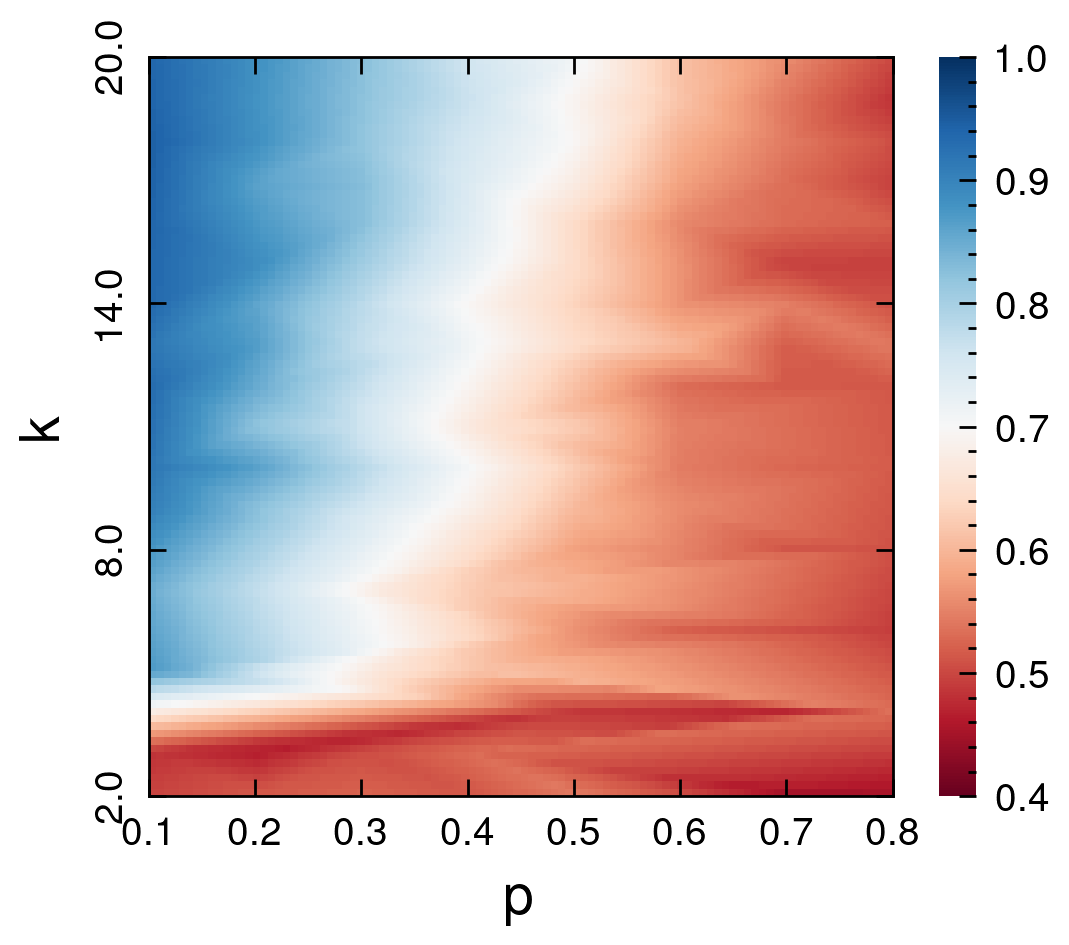

In [ ]:
data_300 = pd.read_csv('ws_core_300.csv')
df = data_300.drop_duplicates(subset=['k', 'p'])
df
X1 = data_300['p']
Y1 = data_300['k'][::-1]


for measure in ['sn_auc','tn_auc','un_auc','rn_auc']:
    Values1 = data_300[measure]
    
    X = X1# + X2
    Y = Y1 #+ Y2
    Values = Values1 #+ Values2

    
    x_min, x_max = min(X), max(X)
    y_min, y_max = min(Y), max(Y)

    
    x_range = np.linspace(x_min, x_max, 100)
    y_range = np.linspace(y_min, y_max, 100)
    X_grid, Y_grid = np.meshgrid(x_range, y_range)

    
    points = np.array([X, Y]).T
    values = np.array(Values)
    Z_interpolated = griddata(points, values, (X_grid, Y_grid), method='linear')

    
    mask = np.isnan(Z_interpolated)


    fig, ax = plt.subplots(figsize=(3, 2.4), dpi=400)
    vmin = 0.4#max(min(values), np.percentile(values, 25)) 
    vmax = 1 # max(values)

  
    x_ticks = np.linspace(x_min, x_max, 8 )  
    y_ticks = np.linspace(y_max, y_min, 4)  

   
    sns.heatmap(Z_interpolated, mask=mask, annot=False, cmap='RdBu', vmin=vmin, vmax=vmax)#, 
                # xticklabels=np.round(x_ticks, 2), yticklabels=np.round(y_ticks, 2))

    # plt.xticks(np.linspace(0.1,0.8,7))
    # plt.title('',fontsize=5)
    plt.ylabel('k',fontsize=10)
    plt.xlabel('p',fontsize=10)

 
    ax = plt.gca()


    ax.set_xticks(np.linspace(0, Z_interpolated.shape[1],8))  
    ax.set_yticks(np.linspace(0, Z_interpolated.shape[0], 4))  

    x_labels = np.round(np.linspace(x_min, x_max, 8),1)
    y_labels = np.linspace(y_min, y_max, 4)[::-1]
    ax.set_xticklabels(x_labels)
    ax.set_yticklabels(y_labels)
    # ax.set_xlim([0,1])

    ax.tick_params(axis='both', which='minor', bottom=False, top=False, left=False, right=False)

    # 
    ax.spines['top'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['left'].set_visible(True)

    filename = f'C:\\Users\\WENJIA\\Downloads\\wsnet\\wsnet_{measure}_core_auc_300.pdf'
    fig.savefig(filename, dpi=800)
    plt.show()


    plt.show()
 

C:\Users\WENJIA\AppData\Local\Temp\ipykernel_46824\2280075522.py:58: UserWarning: FixedFormatter should only be used together with FixedLocator
  cbar.set_ticklabels(np.round(cbar.get_ticks(), 2))  # 四舍五入到两位小数


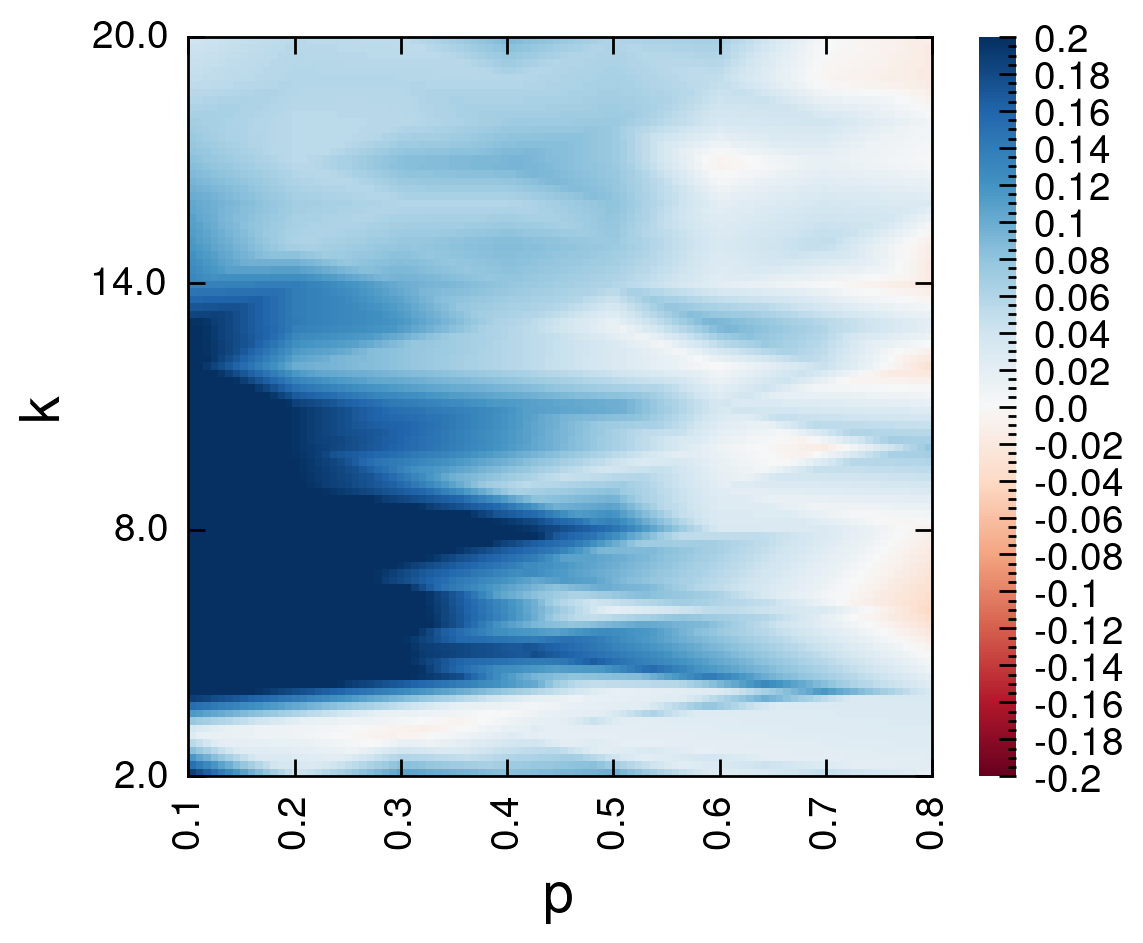

In [ ]:
import matplotlib.ticker as ticker
from matplotlib.colors import BoundaryNorm
Values1 = data_300['sn_auc']

X = X1# + X2
Y = Y1 #+ Y2
Values = Values1 #+ Values2

x_min, x_max = min(X), max(X)
y_min, y_max = min(Y), max(Y)

x_range = np.linspace(x_min, x_max, 100)
y_range = np.linspace(y_min, y_max, 100)
X_grid, Y_grid = np.meshgrid(x_range, y_range)

points = np.array([X, Y]).T
values = np.array(Values)
Z_interpolated_sn = griddata(points, values, (X_grid, Y_grid), method='linear')

Values1 = data_300['tn_auc']

X = X1# + X2
Y = Y1 #+ Y2
Values = Values1 #+ Values2

x_min, x_max = min(X), max(X)
y_min, y_max = min(Y), max(Y)

x_range = np.linspace(x_min, x_max, 100)
y_range = np.linspace(y_min, y_max, 100)
X_grid, Y_grid = np.meshgrid(x_range, y_range)

points = np.array([X, Y]).T
values = np.array(Values)
Z_interpolated_tn = griddata(points, values, (X_grid, Y_grid), method='linear')

Z_interpolated_imp = (Z_interpolated_sn - Z_interpolated_tn)/Z_interpolated_tn



mask = np.isnan(Z_interpolated_imp)

# 
fig, ax = plt.subplots(figsize=(3, 2.4), dpi=400)
vmin = -0.2#max(min(values), np.percentile(values, 25)) 
vmax = 0.2 # max(values)

# 
x_ticks = np.linspace(x_min, x_max, 8 )  
y_ticks = np.linspace(y_max, y_min, 4)  

# 
heatmap =sns.heatmap(Z_interpolated_imp, mask=mask, annot=False, cmap='RdBu', vmin=vmin, vmax=vmax, \
            xticklabels=np.round(x_ticks, 2), yticklabels=np.round(y_ticks, 2))

cbar = heatmap.collections[0].colorbar
cbar.set_ticks(ticker.MultipleLocator(base=0.02))  
cbar.set_ticklabels(np.round(cbar.get_ticks(), 2))  # 四舍五入到两位小数

# plt.xticks(np.linspace(0.1,0.8,7))
# plt.title('',fontsize=5)
plt.ylabel('k',fontsize=10)
plt.xlabel('p',fontsize=10)

# 
ax = plt.gca()

# 
ax.set_xticks(np.linspace(0, Z_interpolated_imp.shape[1],8))  
ax.set_yticks(np.linspace(0, Z_interpolated_imp.shape[0], 4))  

x_labels = np.round(np.linspace(x_min, x_max, 8),1)
y_labels = np.linspace(y_min, y_max, 4)[::-1]
ax.set_xticklabels(x_labels)
ax.set_yticklabels(y_labels)
# ax.set_xlim([0,1])

ax.tick_params(axis='both', which='minor', bottom=False, top=False, left=False, right=False)

# 
ax.spines['top'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['left'].set_visible(True)



filename = f'C:\\Users\\WENJIA\\Downloads\\wsnet\\wsnet_{measure}_core_auc_imp_300.pdf'
fig.savefig(filename, dpi=300)
plt.show()


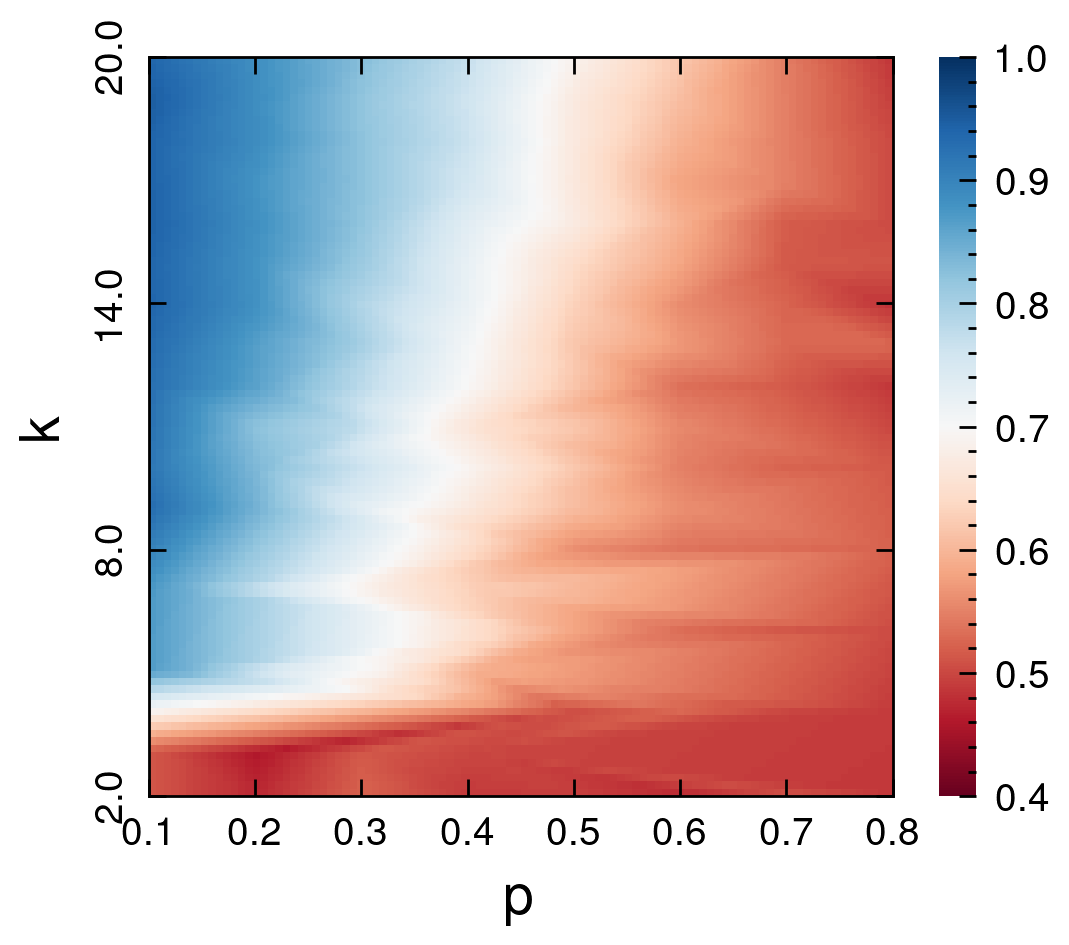

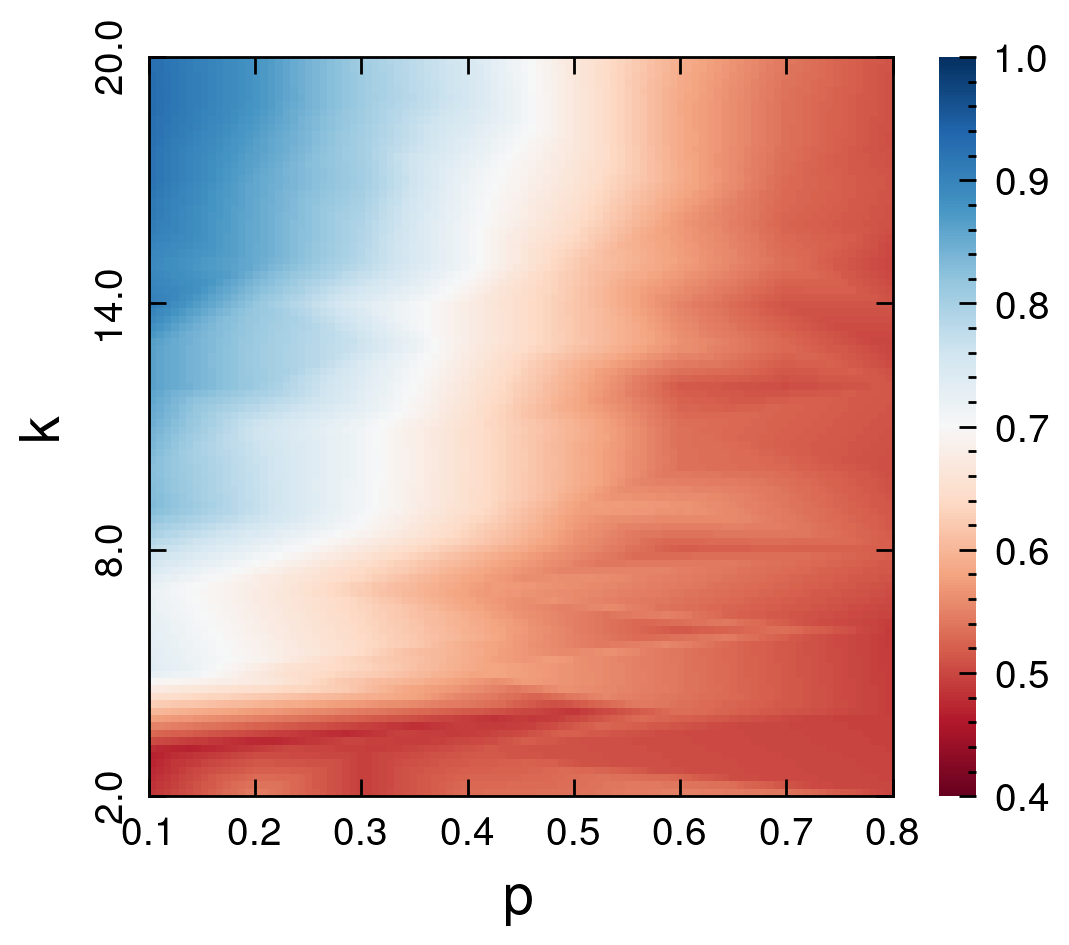

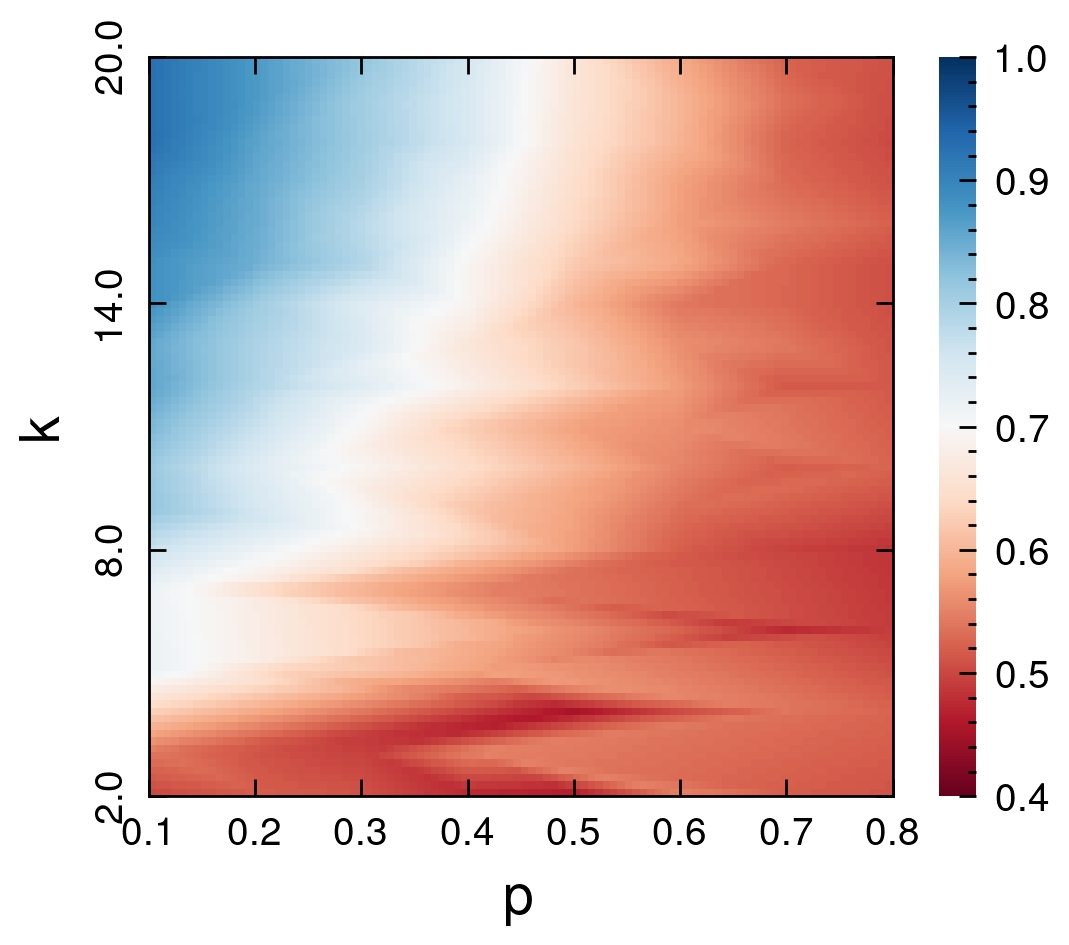

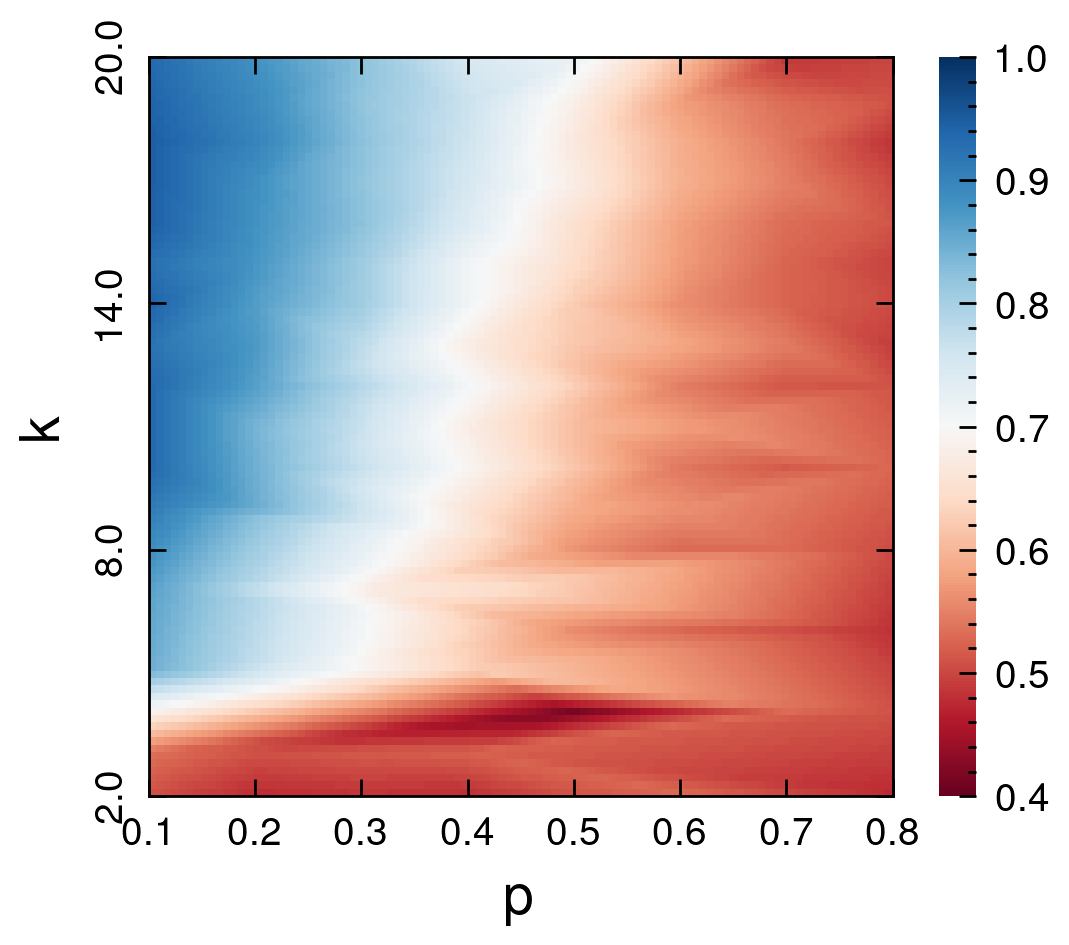

In [ ]:
data_300 = pd.read_csv('ws_pagerank_300.csv')
df = data_300.drop_duplicates(subset=['k', 'p'])
df
X1 = data_300['p']
Y1 = data_300['k'][::-1]


for measure in ['sn_auc','tn_auc','un_auc','rn_auc']:
    Values1 = data_300[measure]
    
    X = X1# + X2
    Y = Y1 #+ Y2
    Values = Values1 #+ Values2

    
    x_min, x_max = min(X), max(X)
    y_min, y_max = min(Y), max(Y)

    
    x_range = np.linspace(x_min, x_max, 100)
    y_range = np.linspace(y_min, y_max, 100)
    X_grid, Y_grid = np.meshgrid(x_range, y_range)

    
    points = np.array([X, Y]).T
    values = np.array(Values)
    Z_interpolated = griddata(points, values, (X_grid, Y_grid), method='linear')

    
    mask = np.isnan(Z_interpolated)


    fig, ax = plt.subplots(figsize=(3, 2.4), dpi=400)
    vmin = 0.4#max(min(values), np.percentile(values, 25)) 
    vmax = 1 # max(values)

  
    x_ticks = np.linspace(x_min, x_max, 8 )  
    y_ticks = np.linspace(y_max, y_min, 4)  

   
    sns.heatmap(Z_interpolated, mask=mask, annot=False, cmap='RdBu', vmin=vmin, vmax=vmax)#, 
                # xticklabels=np.round(x_ticks, 2), yticklabels=np.round(y_ticks, 2))

    # plt.xticks(np.linspace(0.1,0.8,7))
    # plt.title('',fontsize=5)
    plt.ylabel('k',fontsize=10)
    plt.xlabel('p',fontsize=10)

 
    ax = plt.gca()


    ax.set_xticks(np.linspace(0, Z_interpolated.shape[1],8))  
    ax.set_yticks(np.linspace(0, Z_interpolated.shape[0], 4))  

    x_labels = np.round(np.linspace(x_min, x_max, 8),1)
    y_labels = np.linspace(y_min, y_max, 4)[::-1]
    ax.set_xticklabels(x_labels)
    ax.set_yticklabels(y_labels)
    # ax.set_xlim([0,1])

    ax.tick_params(axis='both', which='minor', bottom=False, top=False, left=False, right=False)

    # 
    ax.spines['top'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['left'].set_visible(True)

    filename = f'C:\\Users\\WENJIA\\Downloads\\wsnet\\wsnet_{measure}_pagerank_auc_300.pdf'
    fig.savefig(filename, dpi=800)
    plt.show()


    plt.show()
 

C:\Users\WENJIA\AppData\Local\Temp\ipykernel_46824\1001562636.py:58: UserWarning: FixedFormatter should only be used together with FixedLocator
  cbar.set_ticklabels(np.round(cbar.get_ticks(), 2))  # 四舍五入到两位小数


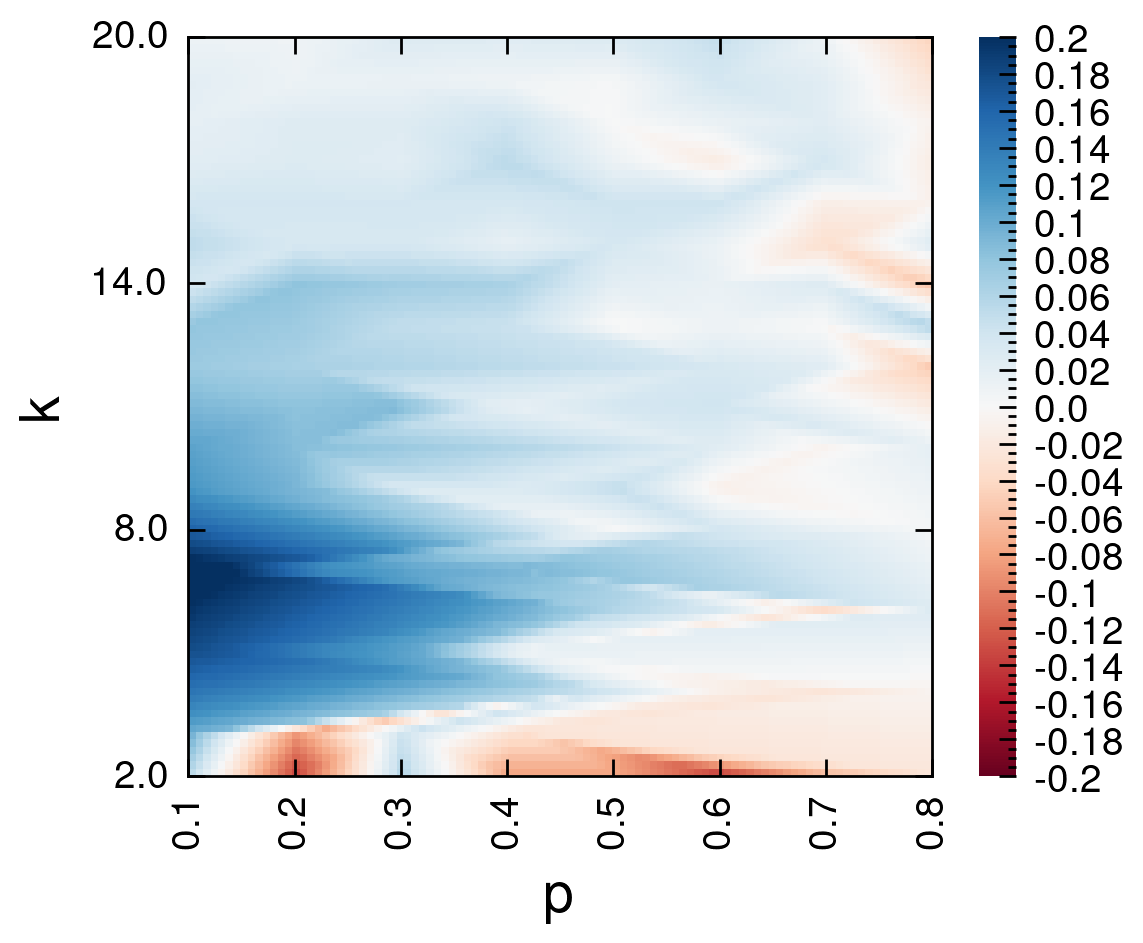

In [ ]:
import matplotlib.ticker as ticker
from matplotlib.colors import BoundaryNorm
Values1 = data_300['sn_auc']

X = X1# + X2
Y = Y1 #+ Y2
Values = Values1 #+ Values2

x_min, x_max = min(X), max(X)
y_min, y_max = min(Y), max(Y)

x_range = np.linspace(x_min, x_max, 100)
y_range = np.linspace(y_min, y_max, 100)
X_grid, Y_grid = np.meshgrid(x_range, y_range)

points = np.array([X, Y]).T
values = np.array(Values)
Z_interpolated_sn = griddata(points, values, (X_grid, Y_grid), method='linear')

Values1 = data_300['tn_auc']

X = X1# + X2
Y = Y1 #+ Y2
Values = Values1 #+ Values2

x_min, x_max = min(X), max(X)
y_min, y_max = min(Y), max(Y)

x_range = np.linspace(x_min, x_max, 100)
y_range = np.linspace(y_min, y_max, 100)
X_grid, Y_grid = np.meshgrid(x_range, y_range)

points = np.array([X, Y]).T
values = np.array(Values)
Z_interpolated_tn = griddata(points, values, (X_grid, Y_grid), method='linear')

Z_interpolated_imp = (Z_interpolated_sn - Z_interpolated_tn)/Z_interpolated_tn



mask = np.isnan(Z_interpolated_imp)

# 
fig, ax = plt.subplots(figsize=(3, 2.4), dpi=400)
vmin = -0.2#max(min(values), np.percentile(values, 25)) 
vmax = 0.2 # max(values)

# 
x_ticks = np.linspace(x_min, x_max, 8 )  
y_ticks = np.linspace(y_max, y_min, 4)  

# 
heatmap =sns.heatmap(Z_interpolated_imp, mask=mask, annot=False, cmap='RdBu', vmin=vmin, vmax=vmax, \
            xticklabels=np.round(x_ticks, 2), yticklabels=np.round(y_ticks, 2))

cbar = heatmap.collections[0].colorbar
cbar.set_ticks(ticker.MultipleLocator(base=0.02))  
cbar.set_ticklabels(np.round(cbar.get_ticks(), 2))  # 

# plt.xticks(np.linspace(0.1,0.8,7))
# plt.title('',fontsize=5)
plt.ylabel('k',fontsize=10)
plt.xlabel('p',fontsize=10)

# 
ax = plt.gca()

# 
ax.set_xticks(np.linspace(0, Z_interpolated_imp.shape[1],8))  
ax.set_yticks(np.linspace(0, Z_interpolated_imp.shape[0], 4))  

x_labels = np.round(np.linspace(x_min, x_max, 8),1)
y_labels = np.linspace(y_min, y_max, 4)[::-1]
ax.set_xticklabels(x_labels)
ax.set_yticklabels(y_labels)
# ax.set_xlim([0,1])

ax.tick_params(axis='both', which='minor', bottom=False, top=False, left=False, right=False)

# 
ax.spines['top'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['left'].set_visible(True)



filename = f'C:\\Users\\WENJIA\\Downloads\\wsnet\\wsnet_{measure}_pagarank_auc_imp_300.pdf'
fig.savefig(filename, dpi=300)
plt.show()


In [2]:
data_150 = pd.read_csv('ws_degree_150.csv')
df = data_150.drop_duplicates(subset=['k', 'p'])
df

,k,p,sn_auc,sn_ap,tn_auc,tn_ap,un_auc,un_ap,rn_auc,rn_ap
0,2,0.1,0.508294,0.484456,0.509674,0.505649,0.506029,0.513644,0.500900,0.488020
1,2,0.2,0.511250,0.499608,0.503265,0.510279,0.503904,0.504827,0.496833,0.479392
2,2,0.3,0.520861,0.508856,0.461926,0.484031,0.517521,0.522397,0.493972,0.483816
3,2,0.4,0.509153,0.499006,0.522500,0.514342,0.519107,0.517679,0.509917,0.496667
4,2,0.5,0.497986,0.478556,0.492236,0.503098,0.519654,0.524956,0.533217,0.520925
...,...,...,...,...,...,...,...,...,...,...
155,20,0.4,0.735953,0.736802,0.732030,0.749328,0.726728,0.750444,0.750474,0.763358
156,20,0.5,0.658436,0.646738,0.661553,0.684930,0.663023,0.679266,0.647224,0.641795
157,20,0.6,0.542561,0.541994,0.566049,0.564839,0.584567,0.589275,0.544964,0.551516
158,20,0.7,0.472466,0.480378,0.533548,0.536329,0.537496,0.541438,0.473341,0.486004


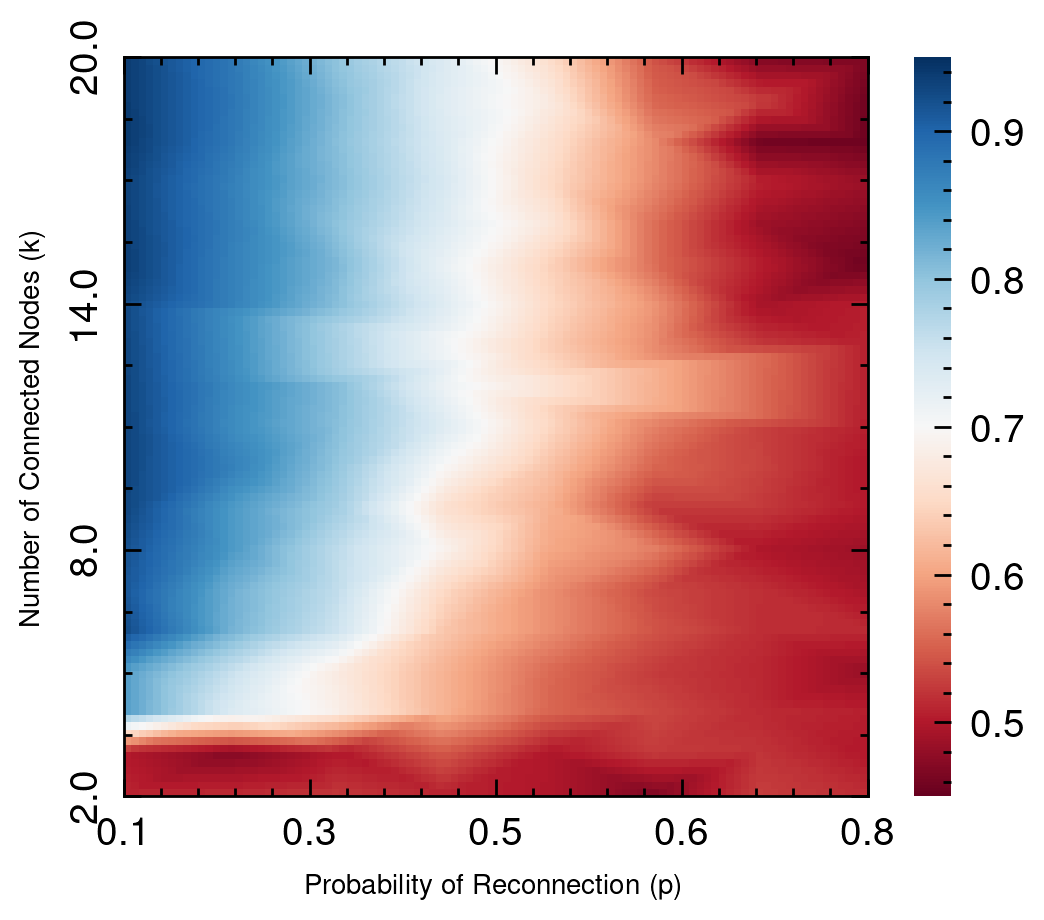

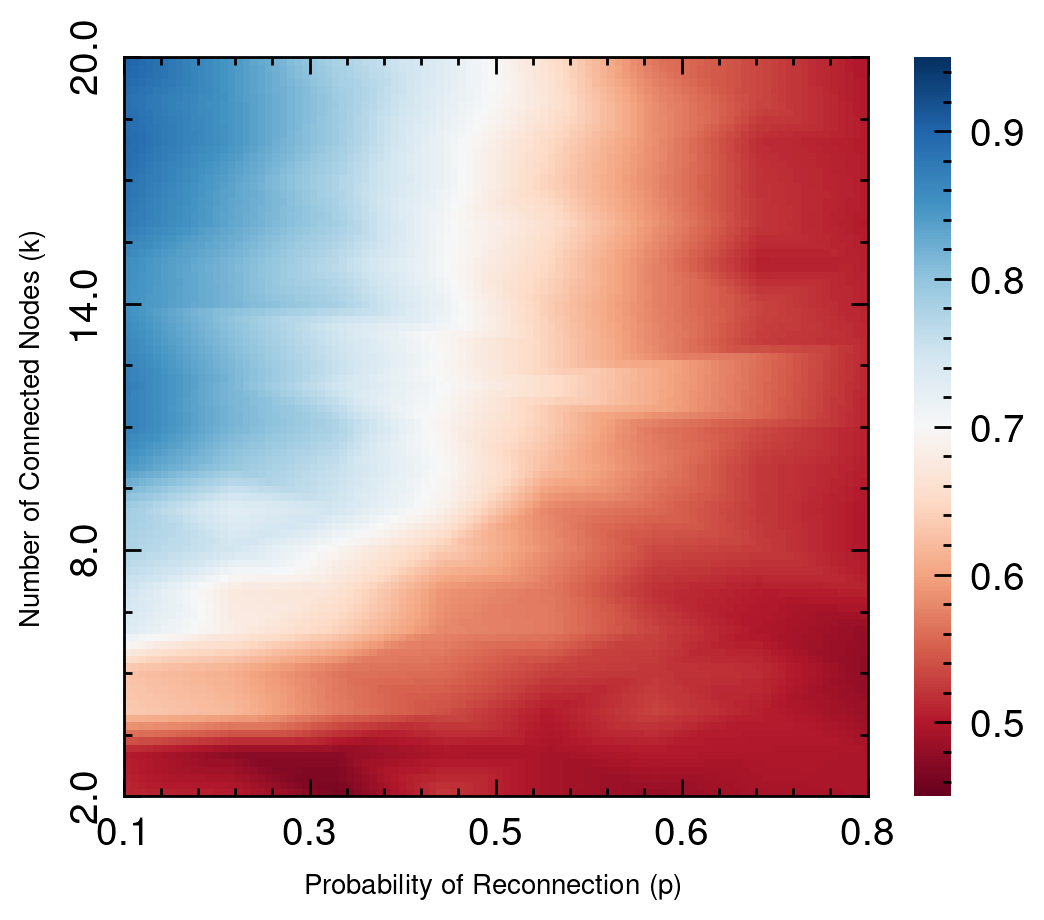

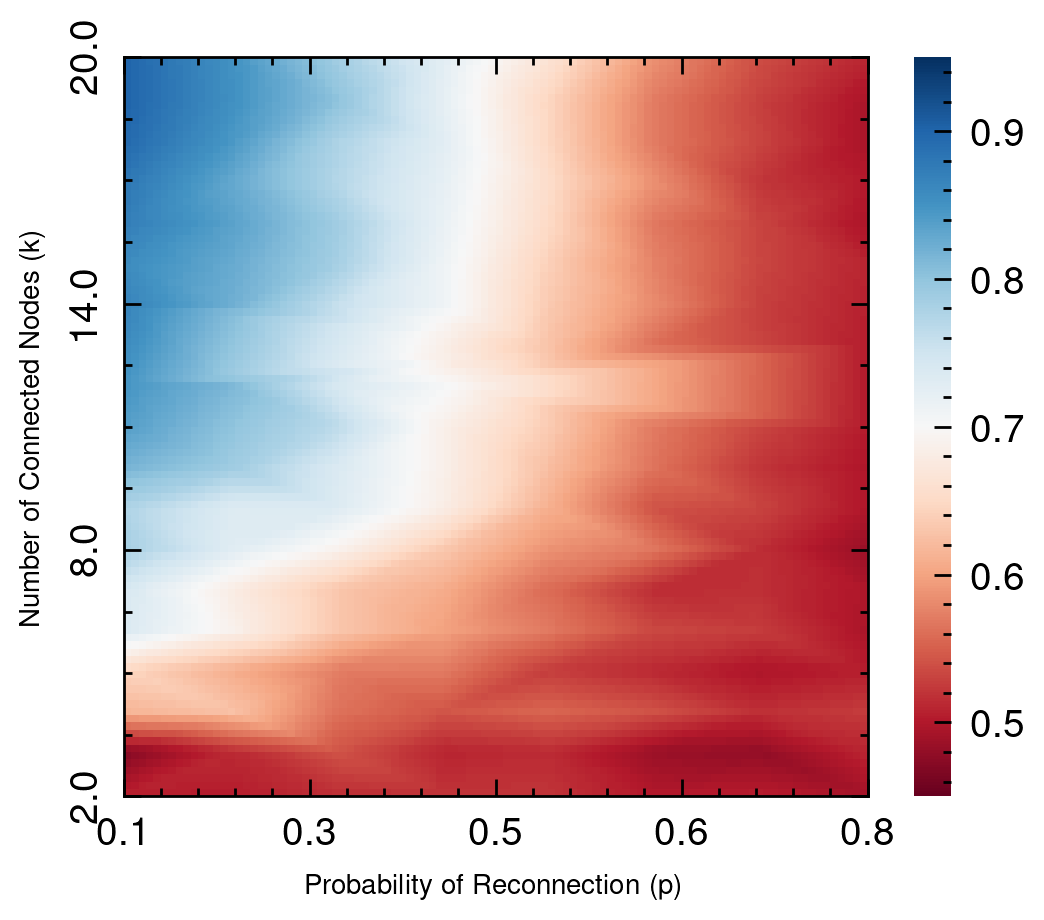

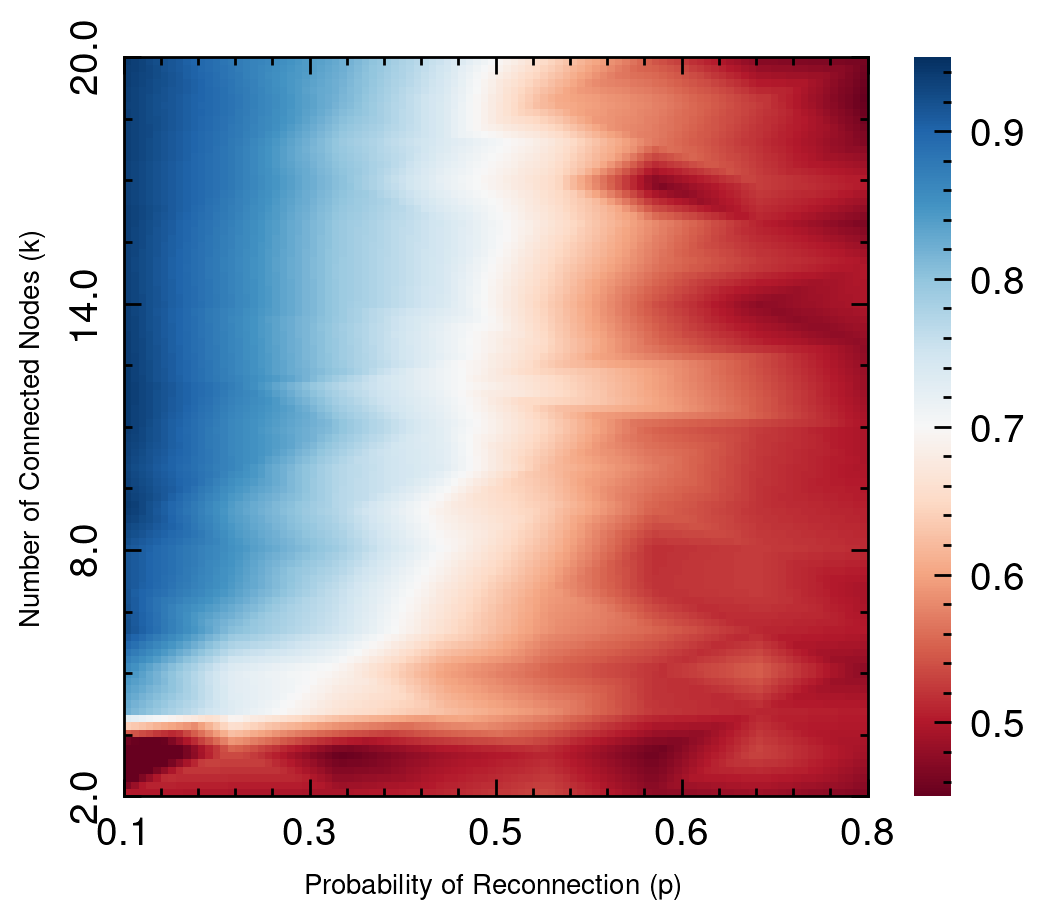

In [ ]:
X1 = data_150['p']
Y1 = data_150['k'][::-1]


for measure in ['sn_auc','tn_auc','un_auc','rn_auc']:
    Values1 = data_150[measure]
    
    X = X1# + X2
    Y = Y1 #+ Y2
    Values = Values1 #+ Values2

    
    x_min, x_max = min(X), max(X)
    y_min, y_max = min(Y), max(Y)

    
    x_range = np.linspace(x_min, x_max, 100)
    y_range = np.linspace(y_min, y_max, 100)
    X_grid, Y_grid = np.meshgrid(x_range, y_range)

    
    points = np.array([X, Y]).T
    values = np.array(Values)
    Z_interpolated = griddata(points, values, (X_grid, Y_grid), method='linear')

    
    mask = np.isnan(Z_interpolated)


    fig, ax = plt.subplots(figsize=(3, 2.4), dpi=400)
    vmin = 0.45#max(min(values), np.percentile(values, 25)) 
    vmax = 0.95 # max(values)

  
    x_ticks = np.linspace(x_min, x_max, 5 )  
    y_ticks = np.linspace(y_max, y_min, 4)  

   
    sns.heatmap(Z_interpolated, mask=mask, annot=False, cmap='RdBu', vmin=vmin, vmax=vmax)#, 
                # xticklabels=np.round(x_ticks, 2), yticklabels=np.round(y_ticks, 2))

    # plt.xticks(np.linspace(0.1,0.8,7))
    # plt.title('Centrality Probability Subgraph with 300 nodes on ws3000',fontsize=5)
    plt.ylabel('Number of Connected Nodes (k)',fontsize=5)
    plt.xlabel('Probability of Reconnection (p)',fontsize=5)

 
    ax = plt.gca()


    ax.set_xticks(np.linspace(0, Z_interpolated.shape[1],5))  
    ax.set_yticks(np.linspace(0, Z_interpolated.shape[0], 4))  

    x_labels = np.round(np.linspace(x_min, x_max, 5),1)
    y_labels = np.linspace(y_min, y_max, 4)[::-1]
    ax.set_xticklabels(x_labels)
    ax.set_yticklabels(y_labels)
    # ax.set_xlim([0,1])




    # 
    ax.spines['top'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['left'].set_visible(True)

    filename = f'C:\\Users\\WENJIA\\Downloads\\wsnet\\wsnet_{measure}_degree_auc_150.pdf'
    fig.savefig(filename, dpi=800)
    plt.show()
 

,k,node,sn_auc,sn_ap,tn_auc,tn_ap,un_auc,un_ap,rn_auc,rn_ap
0,2,75,0.498421,0.533604,0.499828,0.515872,0.514349,0.519826,0.688397,0.732661
1,2,150,0.504951,0.544449,0.476132,0.501583,0.507806,0.512276,0.488828,0.549960
2,2,225,0.497501,0.540223,0.502587,0.528600,0.514256,0.517023,0.500981,0.553142
3,2,275,0.484106,0.535222,0.499550,0.519199,0.506376,0.523071,0.472318,0.519412
4,2,300,0.498207,0.536522,0.494988,0.546442,0.493712,0.505661,0.506525,0.552762
...,...,...,...,...,...,...,...,...,...,...
355,60,600,0.714919,0.731523,0.594656,0.622846,0.670428,0.687270,0.705558,0.723937
356,60,675,0.704227,0.721550,0.632730,0.654003,0.666404,0.683990,0.707008,0.725591
357,60,750,0.700808,0.717269,0.636049,0.659809,0.658278,0.672175,0.716081,0.732868
358,60,825,0.699318,0.719515,0.649072,0.673800,0.679296,0.698686,0.711808,0.730600


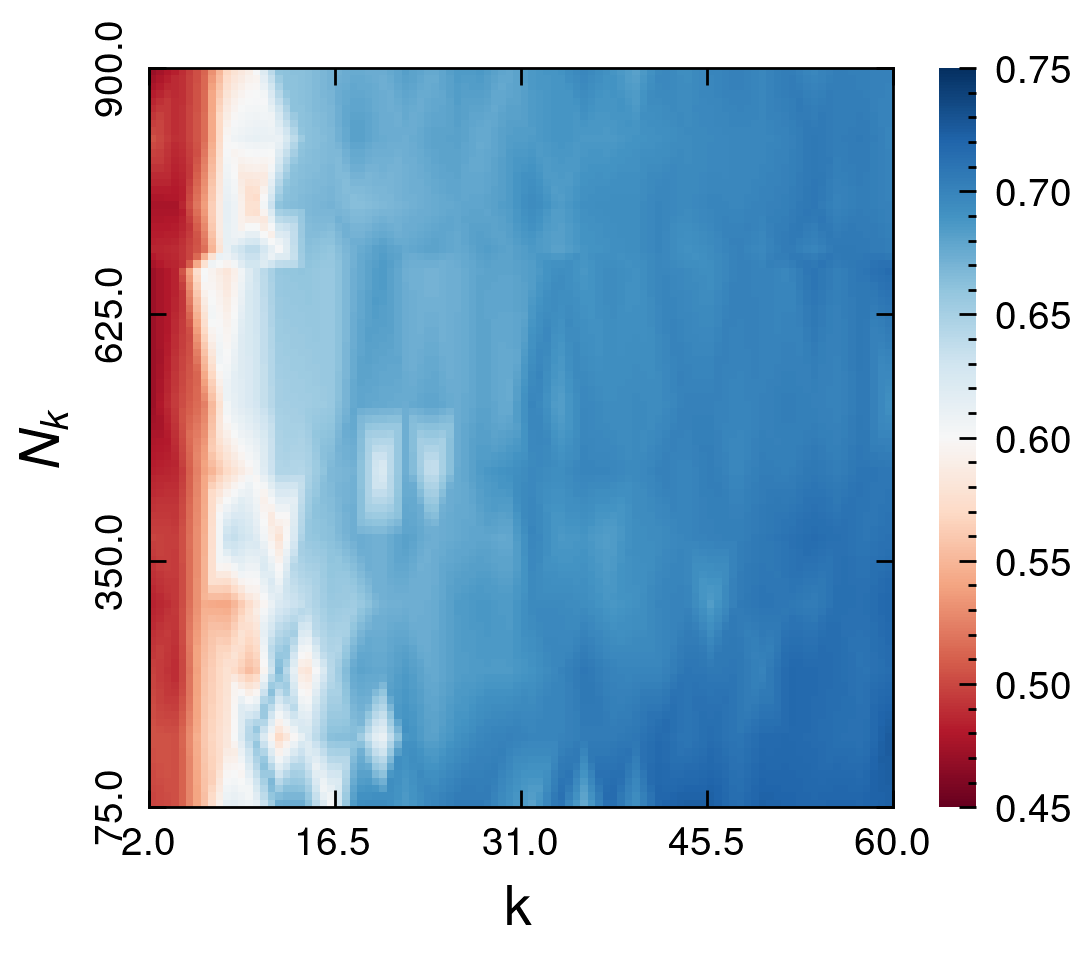

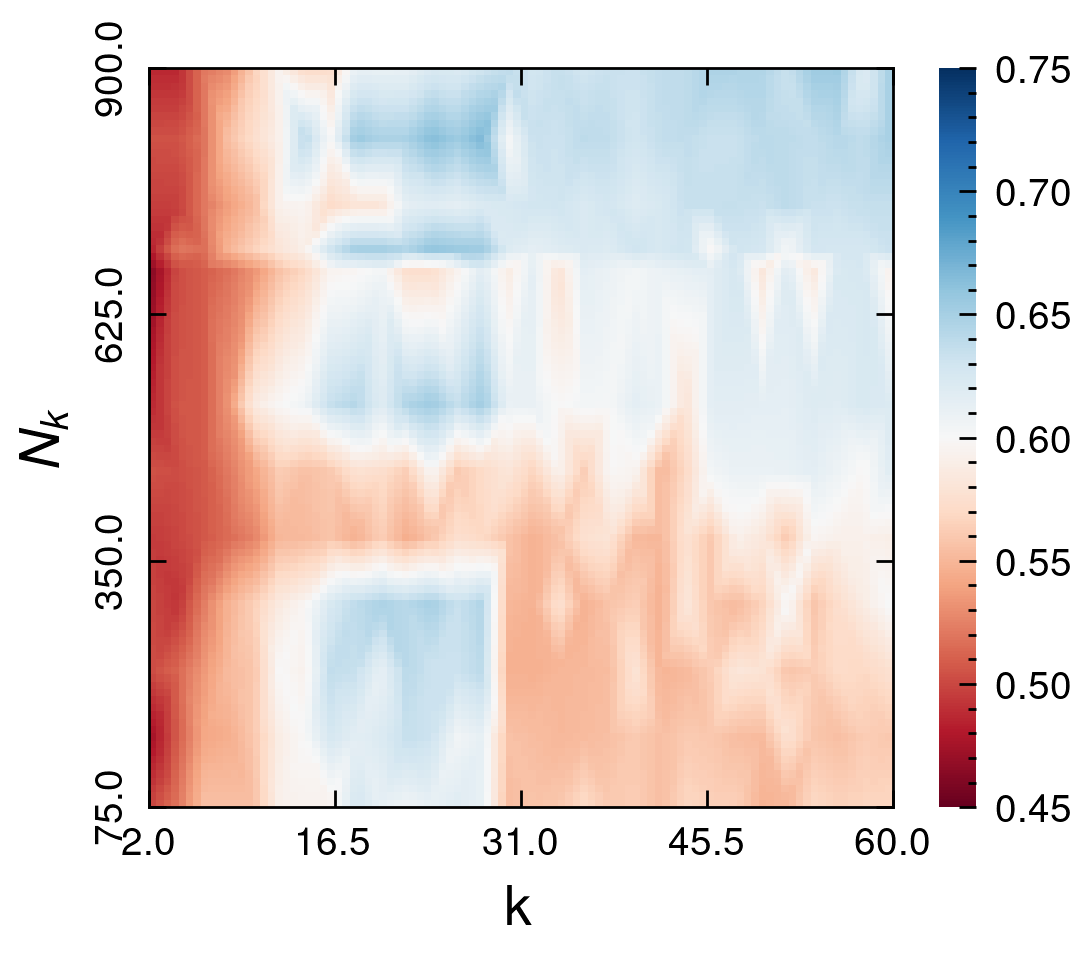

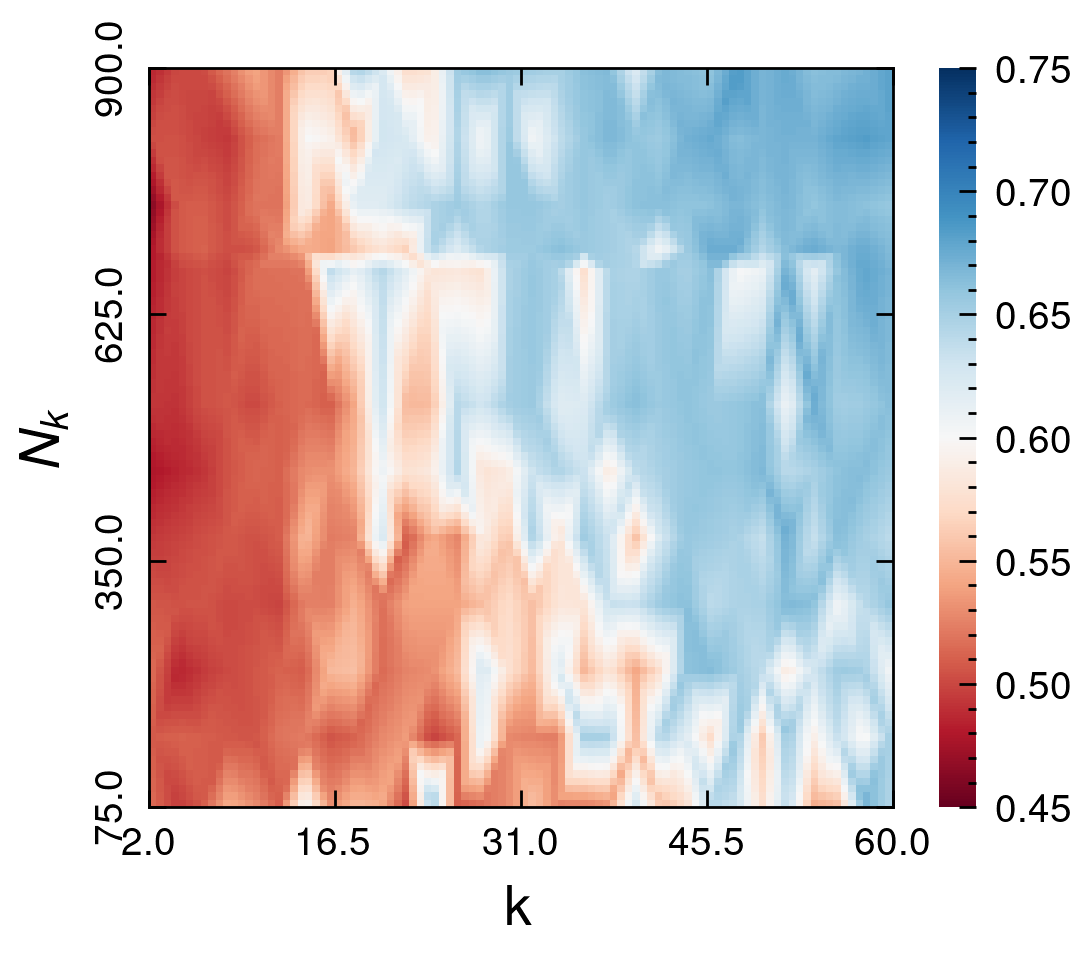

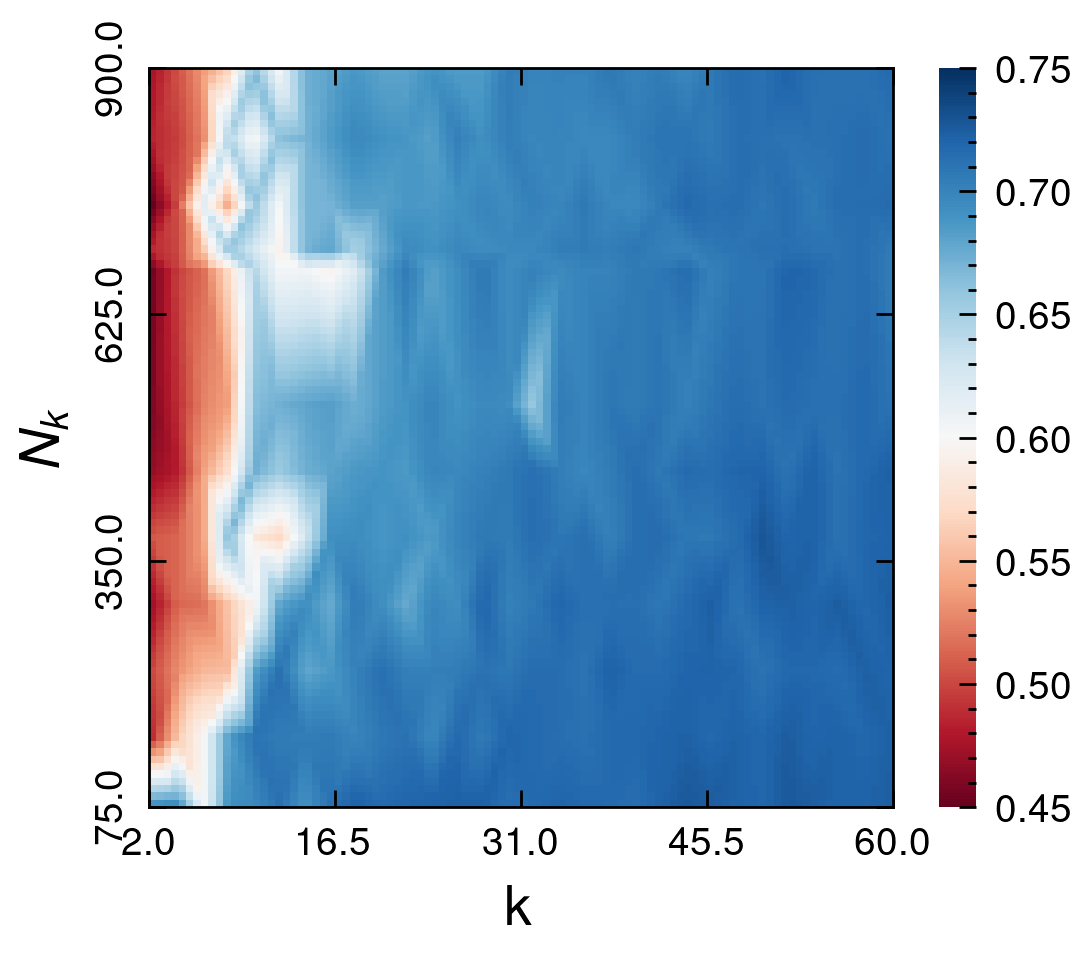

In [ ]:
data_300 = pd.read_csv('ba3k_degree.csv')
df = data_300.drop_duplicates(subset=['k', 'node'])
df
X1 = data_300['k']
Y1 = data_300['node'][::-1]


for measure in ['sn_auc','tn_auc','un_auc','rn_auc']:
    Values1 = data_300[measure]
    
    X = X1# + X2
    Y = Y1 #+ Y2
    Values = Values1 #+ Values2

    
    x_min, x_max = min(X), max(X)
    y_min, y_max = min(Y), max(Y)

    
    x_range = np.linspace(x_min, x_max, 100)
    y_range = np.linspace(y_min, y_max, 100)
    X_grid, Y_grid = np.meshgrid(x_range, y_range)

    
    points = np.array([X, Y]).T
    values = np.array(Values)
    Z_interpolated = griddata(points, values, (X_grid, Y_grid), method='linear')

    
    mask = np.isnan(Z_interpolated)


    fig, ax = plt.subplots(figsize=(3, 2.4), dpi=400)
    vmin = 0.45#max(min(values), np.percentile(values, 25)) 
    vmax = 0.75 # max(values)

  
    x_ticks = np.linspace(x_min, x_max, 5)  
    y_ticks = np.linspace(y_max, y_min, 4)  

   
    sns.heatmap(Z_interpolated, mask=mask, annot=False, cmap='RdBu', vmin=vmin, vmax=vmax)#, 
                # xticklabels=np.round(x_ticks, 2), yticklabels=np.round(y_ticks, 2))

    # plt.xticks(np.linspace(0.1,0.8,7))



    plt.ylabel(r'$N_k$',fontsize=10)
    plt.xlabel('k',fontsize=10)

 
    ax = plt.gca()

    ax.set_xticks(np.linspace(0, Z_interpolated.shape[1],5))  
    ax.set_yticks(np.linspace(0, Z_interpolated.shape[0], 4))  


    x_labels = np.round(np.linspace(x_min, x_max, 5),1)
    y_labels = np.linspace(y_min, y_max, 4)[::-1]
    ax.set_xticklabels(x_labels)
    ax.set_yticklabels(y_labels)
    # ax.set_xlim([0,1])

    ax.tick_params(axis='both', which='minor', bottom=False, top=False, left=False, right=False)

    # 
    ax.spines['top'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['left'].set_visible(True)


    filename = f'C:\\Users\\WENJIA\\Downloads\\banet\\banet_{measure}_degree_auc_300.pdf'
    fig.savefig(filename, dpi=800)
    plt.show()


    plt.show()
 

C:\Users\WENJIA\AppData\Local\Temp\ipykernel_46824\1793323732.py:58: UserWarning: FixedFormatter should only be used together with FixedLocator
  cbar.set_ticklabels(np.round(cbar.get_ticks(), 2))  # 四舍五入到两位小数


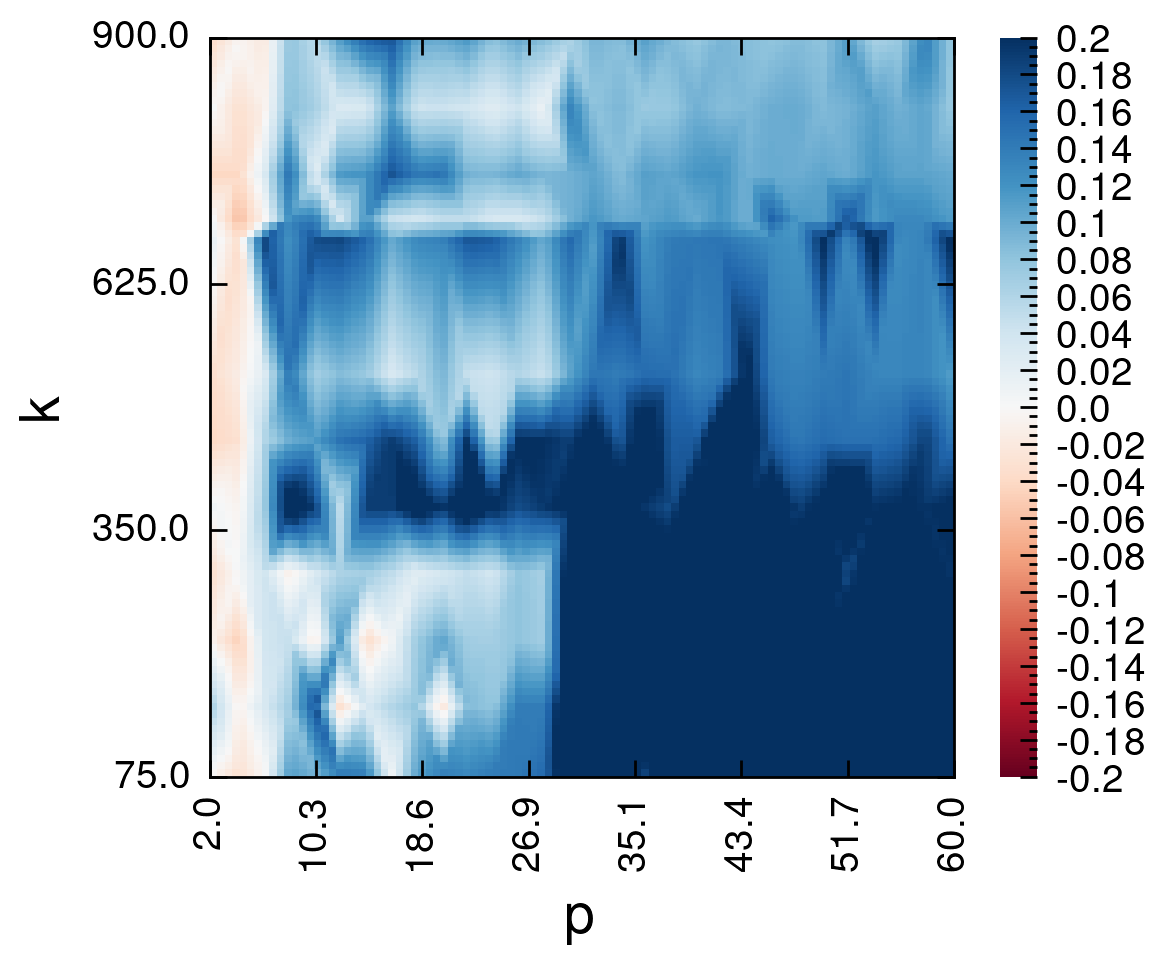

In [ ]:
import matplotlib.ticker as ticker
from matplotlib.colors import BoundaryNorm
Values1 = data_300['sn_auc']

X = X1# + X2
Y = Y1 #+ Y2
Values = Values1 #+ Values2

x_min, x_max = min(X), max(X)
y_min, y_max = min(Y), max(Y)

x_range = np.linspace(x_min, x_max, 100)
y_range = np.linspace(y_min, y_max, 100)
X_grid, Y_grid = np.meshgrid(x_range, y_range)

points = np.array([X, Y]).T
values = np.array(Values)
Z_interpolated_sn = griddata(points, values, (X_grid, Y_grid), method='linear')

Values1 = data_300['tn_auc']

X = X1# + X2
Y = Y1 #+ Y2
Values = Values1 #+ Values2

x_min, x_max = min(X), max(X)
y_min, y_max = min(Y), max(Y)

x_range = np.linspace(x_min, x_max, 100)
y_range = np.linspace(y_min, y_max, 100)
X_grid, Y_grid = np.meshgrid(x_range, y_range)

points = np.array([X, Y]).T
values = np.array(Values)
Z_interpolated_tn = griddata(points, values, (X_grid, Y_grid), method='linear')

Z_interpolated_imp = (Z_interpolated_sn - Z_interpolated_tn)/Z_interpolated_tn



mask = np.isnan(Z_interpolated_imp)

# 
fig, ax = plt.subplots(figsize=(3, 2.4), dpi=400)
vmin = -0.2#max(min(values), np.percentile(values, 25)) 
vmax = 0.2 # max(values)

# 
x_ticks = np.linspace(x_min, x_max, 8 )  
y_ticks = np.linspace(y_max, y_min, 4)  

# 
heatmap =sns.heatmap(Z_interpolated_imp, mask=mask, annot=False, cmap='RdBu', vmin=vmin, vmax=vmax, \
            xticklabels=np.round(x_ticks, 2), yticklabels=np.round(y_ticks, 2))

cbar = heatmap.collections[0].colorbar
cbar.set_ticks(ticker.MultipleLocator(base=0.02))  
cbar.set_ticklabels(np.round(cbar.get_ticks(), 2))  # 四舍五入到两位小数

# plt.xticks(np.linspace(0.1,0.8,7))
# plt.title('',fontsize=5)
plt.ylabel('k',fontsize=10)
plt.xlabel('p',fontsize=10)

# 
ax = plt.gca()

# 
ax.set_xticks(np.linspace(0, Z_interpolated_imp.shape[1],8))  
ax.set_yticks(np.linspace(0, Z_interpolated_imp.shape[0], 4))  

x_labels = np.round(np.linspace(x_min, x_max, 8),1)
y_labels = np.linspace(y_min, y_max, 4)[::-1]
ax.set_xticklabels(x_labels)
ax.set_yticklabels(y_labels)
# ax.set_xlim([0,1])

ax.tick_params(axis='both', which='minor', bottom=False, top=False, left=False, right=False)

# 
ax.spines['top'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['left'].set_visible(True)



filename = f'C:\\Users\\WENJIA\\Downloads\\wsnet\\banet_{measure}_degree_auc_imp_300.pdf'
fig.savefig(filename, dpi=300)
plt.show()


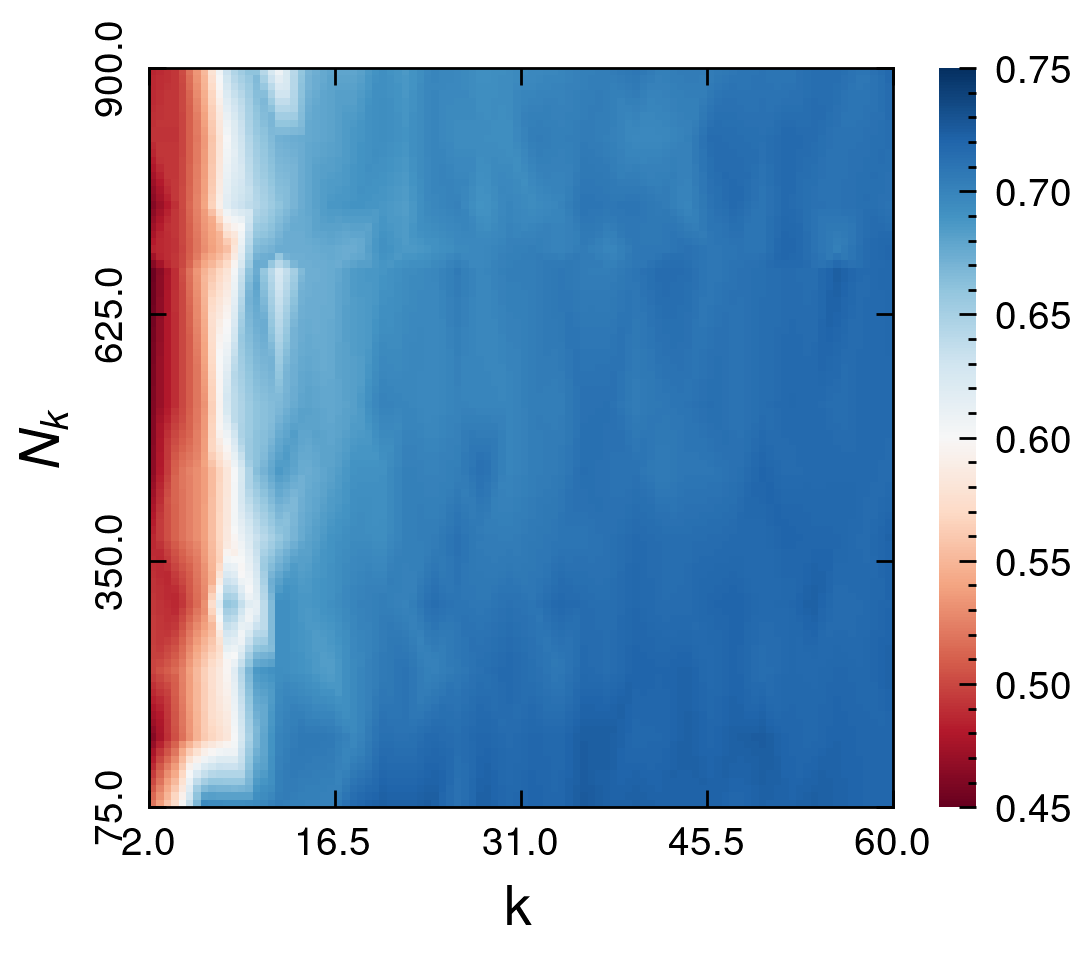

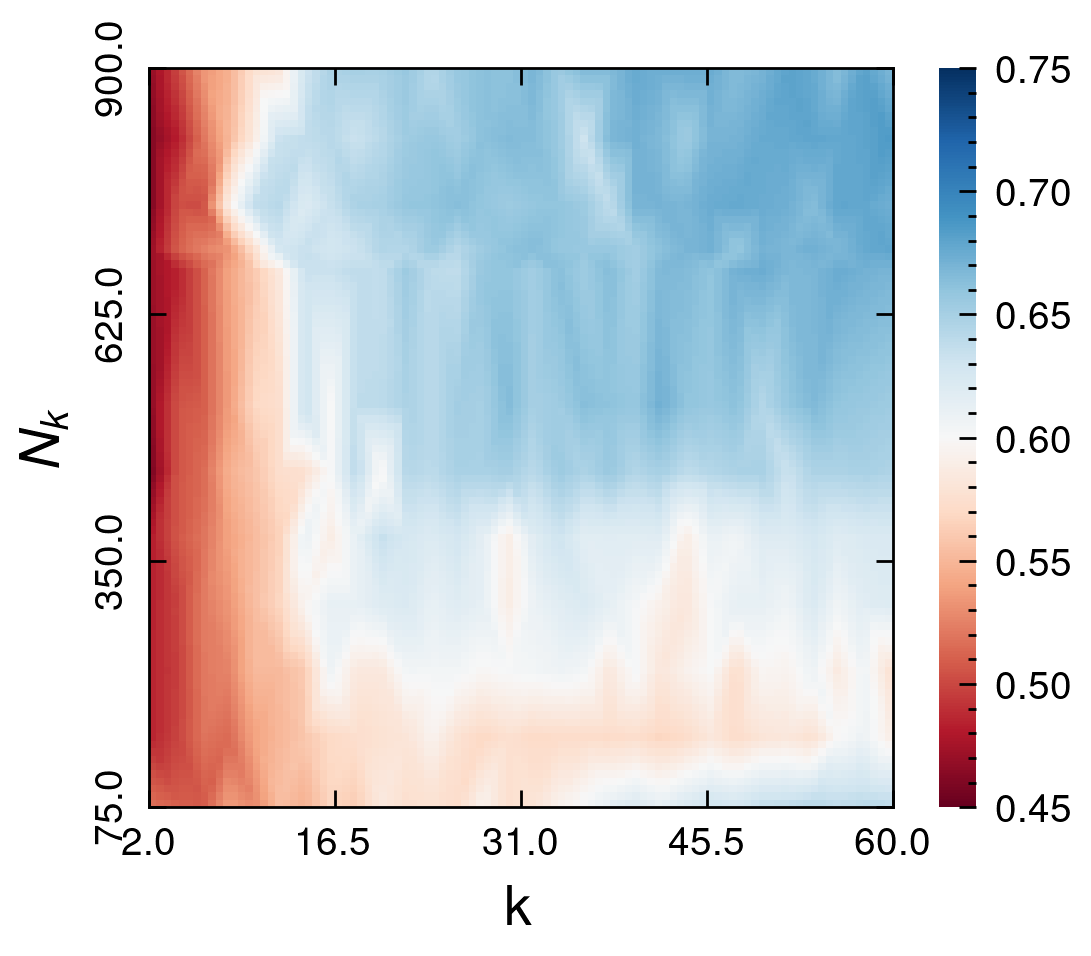

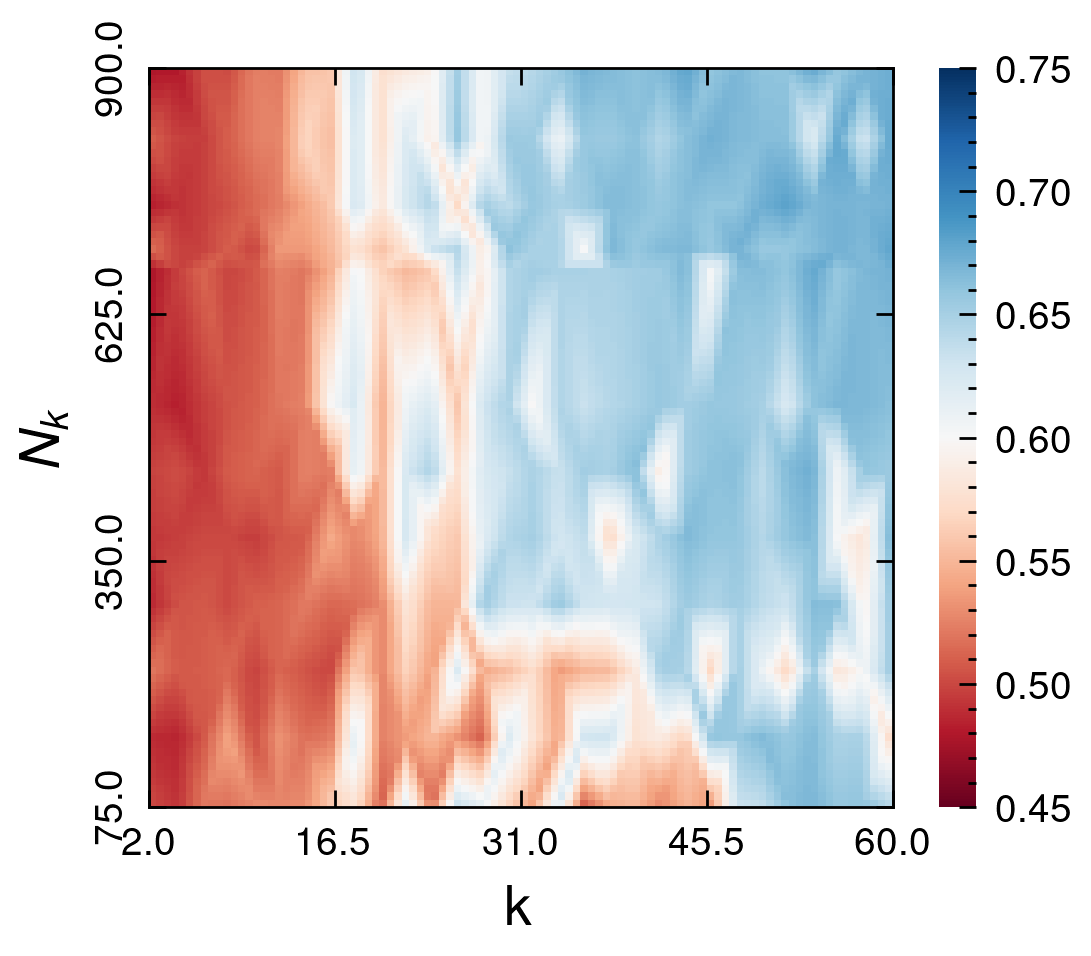

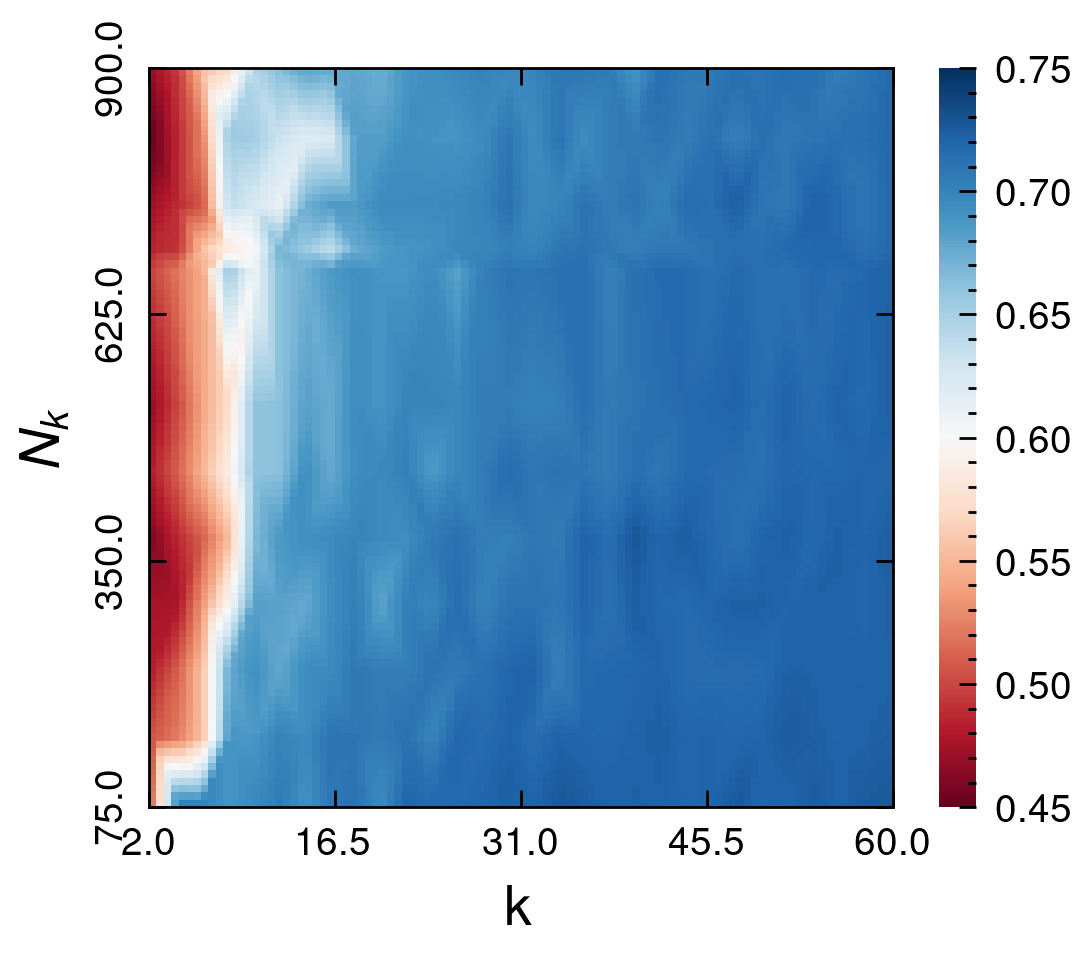

In [ ]:
data_300 = pd.read_csv('ba3k_core.csv')
df = data_300.drop_duplicates(subset=['k', 'node'])
df
X1 = data_300['k']
Y1 = data_300['node'][::-1]


for measure in ['sn_auc','tn_auc','un_auc','rn_auc']:
    Values1 = data_300[measure]
    
    X = X1# + X2
    Y = Y1 #+ Y2
    Values = Values1 #+ Values2

    
    x_min, x_max = min(X), max(X)
    y_min, y_max = min(Y), max(Y)

    
    x_range = np.linspace(x_min, x_max, 100)
    y_range = np.linspace(y_min, y_max, 100)
    X_grid, Y_grid = np.meshgrid(x_range, y_range)

    
    points = np.array([X, Y]).T
    values = np.array(Values)
    Z_interpolated = griddata(points, values, (X_grid, Y_grid), method='linear')

    
    mask = np.isnan(Z_interpolated)


    fig, ax = plt.subplots(figsize=(3, 2.4), dpi=400)
    vmin = 0.45#max(min(values), np.percentile(values, 25)) 
    vmax = 0.75 # max(values)

  
    x_ticks = np.linspace(x_min, x_max, 5)  
    y_ticks = np.linspace(y_max, y_min, 4)  

   
    sns.heatmap(Z_interpolated, mask=mask, annot=False, cmap='RdBu', vmin=vmin, vmax=vmax)#, 
                # xticklabels=np.round(x_ticks, 2), yticklabels=np.round(y_ticks, 2))

    # plt.xticks(np.linspace(0.1,0.8,7))



    plt.ylabel(r'$N_k$',fontsize=10)
    plt.xlabel('k',fontsize=10)

 
    ax = plt.gca()

    ax.set_xticks(np.linspace(0, Z_interpolated.shape[1],5))  
    ax.set_yticks(np.linspace(0, Z_interpolated.shape[0], 4))  


    x_labels = np.round(np.linspace(x_min, x_max, 5),1)
    y_labels = np.linspace(y_min, y_max, 4)[::-1]
    ax.set_xticklabels(x_labels)
    ax.set_yticklabels(y_labels)
    # ax.set_xlim([0,1])

    ax.tick_params(axis='both', which='minor', bottom=False, top=False, left=False, right=False)

    # 
    ax.spines['top'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['left'].set_visible(True)


    filename = f'C:\\Users\\WENJIA\\Downloads\\banet\\banet_{measure}_core_auc_300.pdf'
    fig.savefig(filename, dpi=800)
    plt.show()


    plt.show()
 

C:\Users\WENJIA\AppData\Local\Temp\ipykernel_46824\3429052844.py:58: UserWarning: FixedFormatter should only be used together with FixedLocator
  cbar.set_ticklabels(np.round(cbar.get_ticks(), 2))  # 四舍五入到两位小数


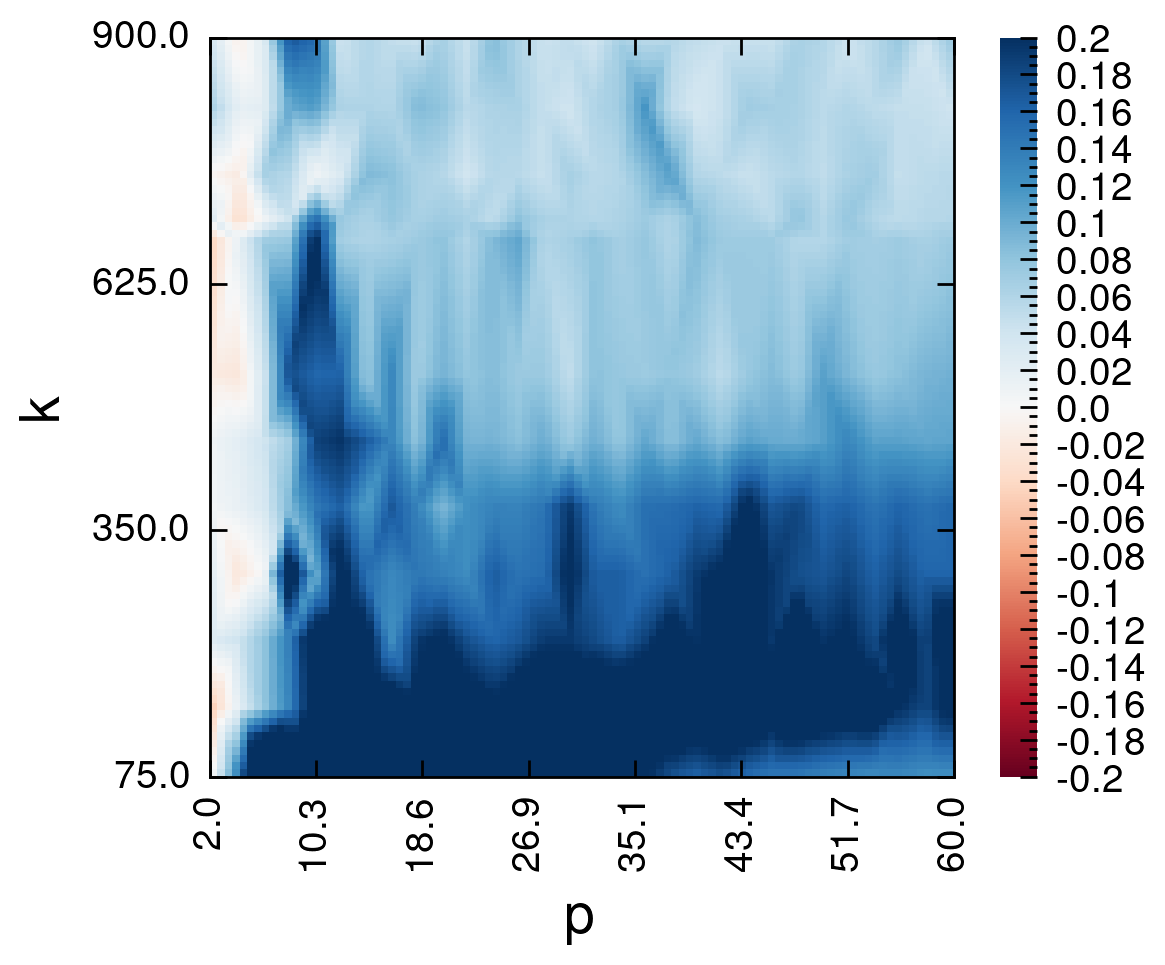

In [ ]:
import matplotlib.ticker as ticker
from matplotlib.colors import BoundaryNorm
Values1 = data_300['sn_auc']

X = X1# + X2
Y = Y1 #+ Y2
Values = Values1 #+ Values2

x_min, x_max = min(X), max(X)
y_min, y_max = min(Y), max(Y)

x_range = np.linspace(x_min, x_max, 100)
y_range = np.linspace(y_min, y_max, 100)
X_grid, Y_grid = np.meshgrid(x_range, y_range)

points = np.array([X, Y]).T
values = np.array(Values)
Z_interpolated_sn = griddata(points, values, (X_grid, Y_grid), method='linear')

Values1 = data_300['tn_auc']

X = X1# + X2
Y = Y1 #+ Y2
Values = Values1 #+ Values2

x_min, x_max = min(X), max(X)
y_min, y_max = min(Y), max(Y)

x_range = np.linspace(x_min, x_max, 100)
y_range = np.linspace(y_min, y_max, 100)
X_grid, Y_grid = np.meshgrid(x_range, y_range)

points = np.array([X, Y]).T
values = np.array(Values)
Z_interpolated_tn = griddata(points, values, (X_grid, Y_grid), method='linear')

Z_interpolated_imp = (Z_interpolated_sn - Z_interpolated_tn)/Z_interpolated_tn



mask = np.isnan(Z_interpolated_imp)

# 
fig, ax = plt.subplots(figsize=(3, 2.4), dpi=400)
vmin = -0.2#max(min(values), np.percentile(values, 25)) 
vmax = 0.2 # max(values)

# 
x_ticks = np.linspace(x_min, x_max, 8 )  
y_ticks = np.linspace(y_max, y_min, 4)  

# 
heatmap =sns.heatmap(Z_interpolated_imp, mask=mask, annot=False, cmap='RdBu', vmin=vmin, vmax=vmax, \
            xticklabels=np.round(x_ticks, 2), yticklabels=np.round(y_ticks, 2))

cbar = heatmap.collections[0].colorbar
cbar.set_ticks(ticker.MultipleLocator(base=0.02))  
cbar.set_ticklabels(np.round(cbar.get_ticks(), 2))  # 四舍五入到两位小数

# plt.xticks(np.linspace(0.1,0.8,7))
# plt.title('',fontsize=5)
plt.ylabel('k',fontsize=10)
plt.xlabel('p',fontsize=10)

# 
ax = plt.gca()

# 
ax.set_xticks(np.linspace(0, Z_interpolated_imp.shape[1],8))  
ax.set_yticks(np.linspace(0, Z_interpolated_imp.shape[0], 4))  

x_labels = np.round(np.linspace(x_min, x_max, 8),1)
y_labels = np.linspace(y_min, y_max, 4)[::-1]
ax.set_xticklabels(x_labels)
ax.set_yticklabels(y_labels)
# ax.set_xlim([0,1])

ax.tick_params(axis='both', which='minor', bottom=False, top=False, left=False, right=False)

# 
ax.spines['top'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['left'].set_visible(True)



filename = f'C:\\Users\\WENJIA\\Downloads\\wsnet\\banet_{measure}_core_auc_imp_300.pdf'
fig.savefig(filename, dpi=300)
plt.show()


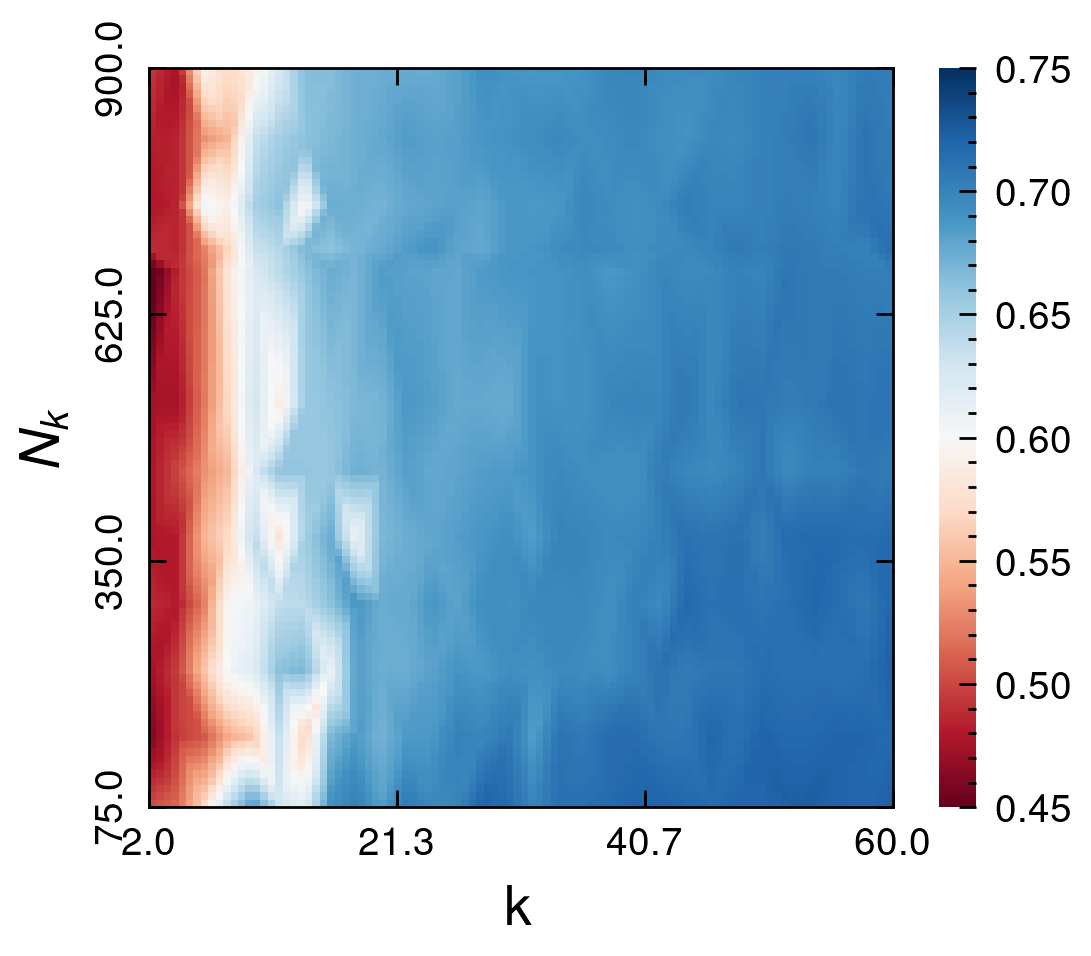

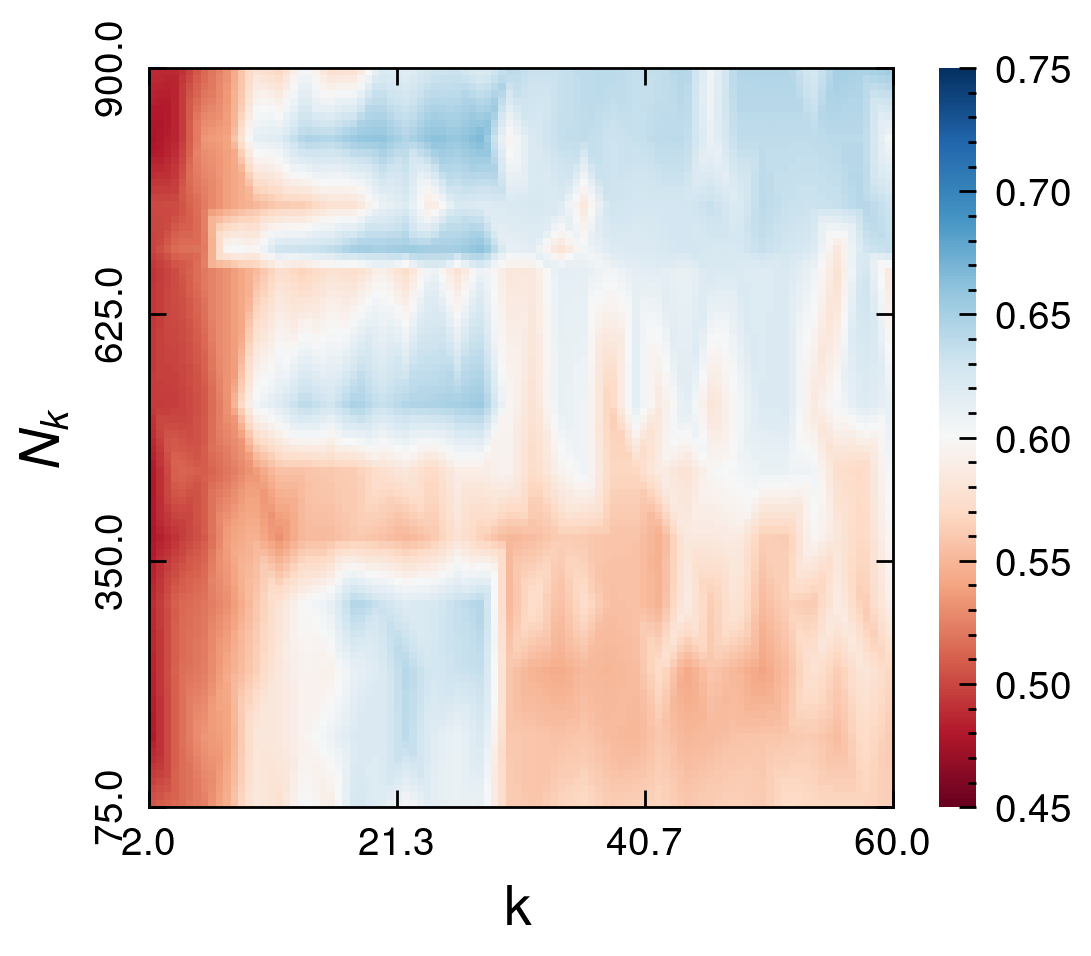

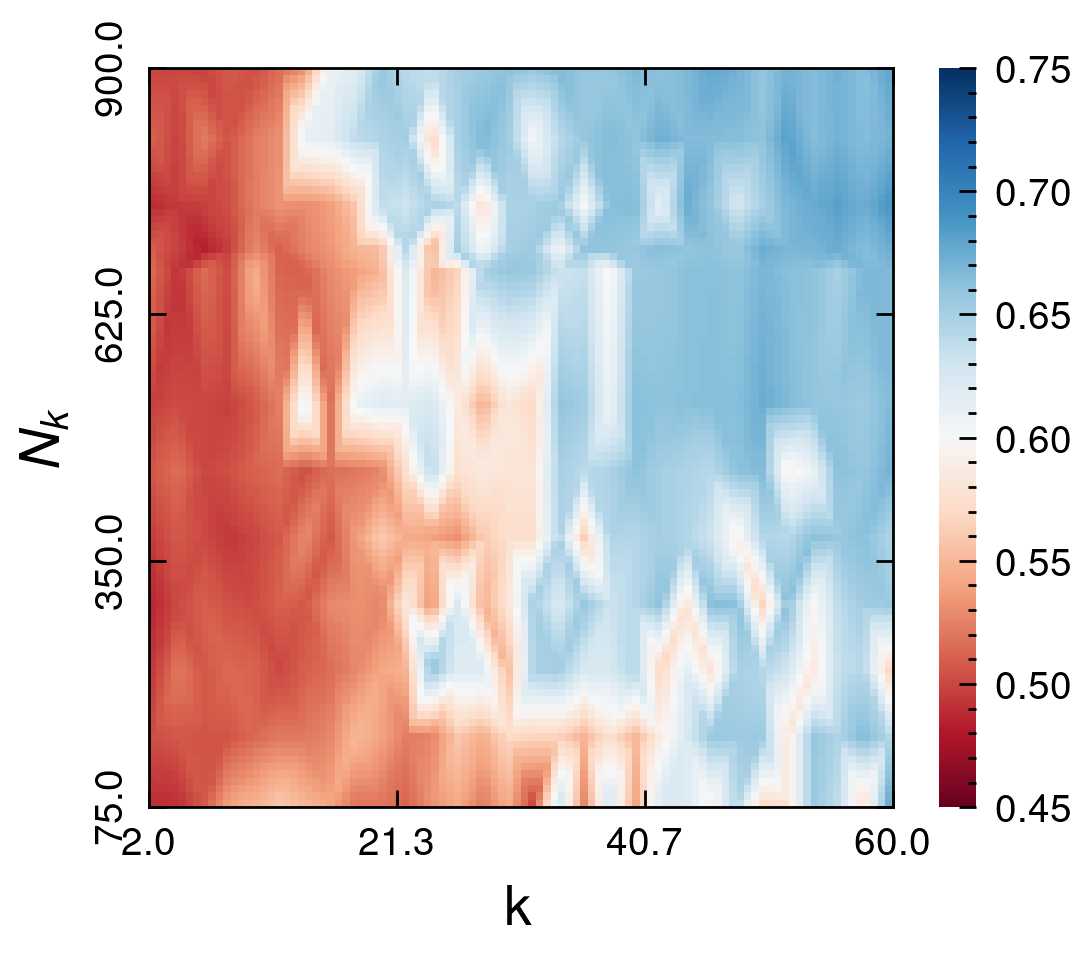

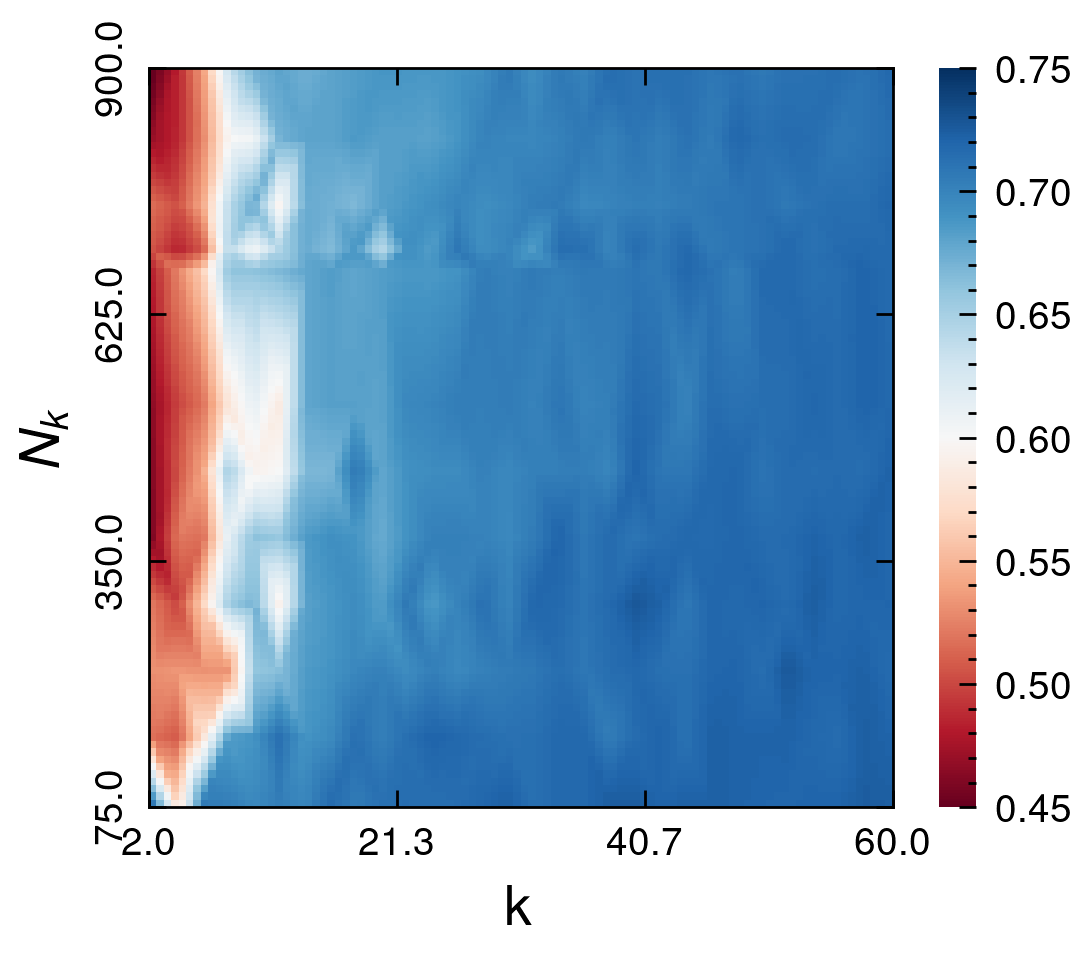

In [ ]:
data_300 = pd.read_csv('ba3k_pagerank.csv')
df = data_300.drop_duplicates(subset=['k', 'node'])
df
X1 = data_300['k']
Y1 = data_300['node'][::-1]


for measure in ['sn_auc','tn_auc','un_auc','rn_auc']:
    Values1 = data_300[measure]
    
    X = X1# + X2
    Y = Y1 #+ Y2
    Values = Values1 #+ Values2

    
    x_min, x_max = min(X), max(X)
    y_min, y_max = min(Y), max(Y)

    
    x_range = np.linspace(x_min, x_max, 100)
    y_range = np.linspace(y_min, y_max, 100)
    X_grid, Y_grid = np.meshgrid(x_range, y_range)

    
    points = np.array([X, Y]).T
    values = np.array(Values)
    Z_interpolated = griddata(points, values, (X_grid, Y_grid), method='linear')

    
    mask = np.isnan(Z_interpolated)


    fig, ax = plt.subplots(figsize=(3, 2.4), dpi=400)
    vmin = 0.45#max(min(values), np.percentile(values, 25)) 
    vmax = 0.75 # max(values)

  
    x_ticks = np.linspace(x_min, x_max, 4)  
    y_ticks = np.linspace(y_max, y_min, 4)  

   
    sns.heatmap(Z_interpolated, mask=mask, annot=False, cmap='RdBu', vmin=vmin, vmax=vmax)#, 
                # xticklabels=np.round(x_ticks, 2), yticklabels=np.round(y_ticks, 2))

    # plt.xticks(np.linspace(0.1,0.8,7))



    plt.ylabel(r'$N_k$',fontsize=10)
    plt.xlabel('k',fontsize=10)

 
    ax = plt.gca()

    ax.set_xticks(np.linspace(0, Z_interpolated.shape[1],4))  
    ax.set_yticks(np.linspace(0, Z_interpolated.shape[0], 4))  


    x_labels = np.round(np.linspace(x_min, x_max, 4),1)
    y_labels = np.linspace(y_min, y_max, 4)[::-1]
    ax.set_xticklabels(x_labels)
    ax.set_yticklabels(y_labels)
    # ax.set_xlim([0,1])

    ax.tick_params(axis='both', which='minor', bottom=False, top=False, left=False, right=False)

    # 
    ax.spines['top'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['left'].set_visible(True)

    filename = f'C:\\Users\\WENJIA\\Downloads\\banet\\banet_{measure}_pagerank_auc_300.pdf'
    fig.savefig(filename, dpi=800)
    plt.show()


    plt.show()
 

C:\Users\WENJIA\AppData\Local\Temp\ipykernel_46824\1176275811.py:58: UserWarning: FixedFormatter should only be used together with FixedLocator
  cbar.set_ticklabels(np.round(cbar.get_ticks(), 2))  # 四舍五入到两位小数


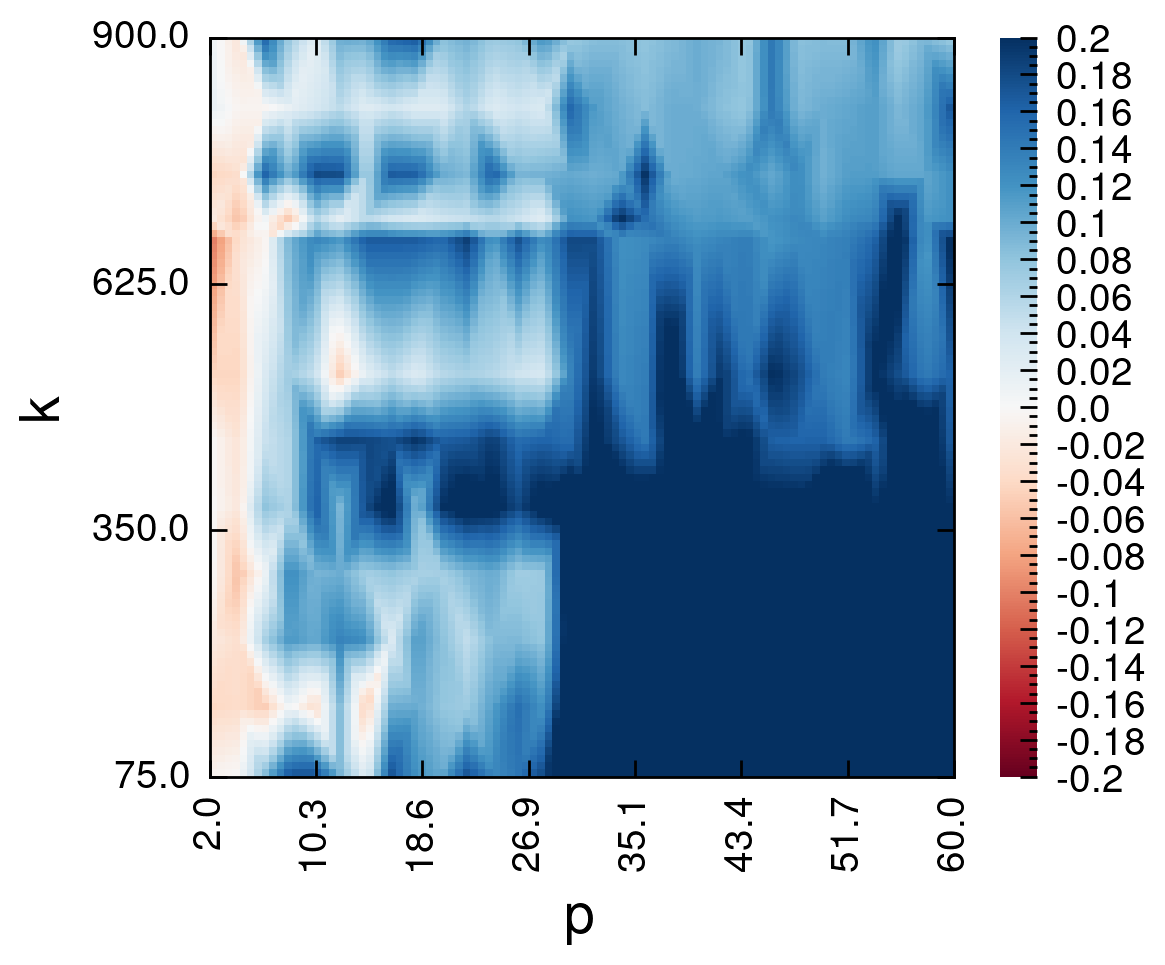

In [ ]:
import matplotlib.ticker as ticker
from matplotlib.colors import BoundaryNorm
Values1 = data_300['sn_auc']

X = X1# + X2
Y = Y1 #+ Y2
Values = Values1 #+ Values2

x_min, x_max = min(X), max(X)
y_min, y_max = min(Y), max(Y)

x_range = np.linspace(x_min, x_max, 100)
y_range = np.linspace(y_min, y_max, 100)
X_grid, Y_grid = np.meshgrid(x_range, y_range)

points = np.array([X, Y]).T
values = np.array(Values)
Z_interpolated_sn = griddata(points, values, (X_grid, Y_grid), method='linear')

Values1 = data_300['tn_auc']

X = X1# + X2
Y = Y1 #+ Y2
Values = Values1 #+ Values2

x_min, x_max = min(X), max(X)
y_min, y_max = min(Y), max(Y)

x_range = np.linspace(x_min, x_max, 100)
y_range = np.linspace(y_min, y_max, 100)
X_grid, Y_grid = np.meshgrid(x_range, y_range)

points = np.array([X, Y]).T
values = np.array(Values)
Z_interpolated_tn = griddata(points, values, (X_grid, Y_grid), method='linear')

Z_interpolated_imp = (Z_interpolated_sn - Z_interpolated_tn)/Z_interpolated_tn



mask = np.isnan(Z_interpolated_imp)

# 
fig, ax = plt.subplots(figsize=(3, 2.4), dpi=400)
vmin = -0.2#max(min(values), np.percentile(values, 25)) 
vmax = 0.2 # max(values)

# 
x_ticks = np.linspace(x_min, x_max, 8 )  
y_ticks = np.linspace(y_max, y_min, 4)  

# 
heatmap =sns.heatmap(Z_interpolated_imp, mask=mask, annot=False, cmap='RdBu', vmin=vmin, vmax=vmax, \
            xticklabels=np.round(x_ticks, 2), yticklabels=np.round(y_ticks, 2))

cbar = heatmap.collections[0].colorbar
cbar.set_ticks(ticker.MultipleLocator(base=0.02))  
cbar.set_ticklabels(np.round(cbar.get_ticks(), 2))  # 四舍五入到两位小数

# plt.xticks(np.linspace(0.1,0.8,7))
# plt.title('',fontsize=5)
plt.ylabel('k',fontsize=10)
plt.xlabel('p',fontsize=10)

# 
ax = plt.gca()

# 
ax.set_xticks(np.linspace(0, Z_interpolated_imp.shape[1],8))  
ax.set_yticks(np.linspace(0, Z_interpolated_imp.shape[0], 4))  

x_labels = np.round(np.linspace(x_min, x_max, 8),1)
y_labels = np.linspace(y_min, y_max, 4)[::-1]
ax.set_xticklabels(x_labels)
ax.set_yticklabels(y_labels)
# ax.set_xlim([0,1])

ax.tick_params(axis='both', which='minor', bottom=False, top=False, left=False, right=False)

# 
ax.spines['top'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['left'].set_visible(True)



filename = f'C:\\Users\\WENJIA\\Downloads\\wsnet\\banet_{measure}_pagerank_auc_imp_300.pdf'
fig.savefig(filename, dpi=300)
plt.show()
